# Computational Intelligence for Optimization — Group Project
## Girl with a Pearl Earring: Image Reconstruction with Genetic Algorithms

---

The challenge is to produce a minimalistic reconstruction of Vermeer's *Girl with a Pearl Earring* using exactly **100 colored triangles**, optimized by a Genetic Algorithm.  
Quality is measured as the pixel-wise **Root Mean Square Error (RMSE)** between the rendered image and the 300×400 original — lower is better.

This notebook is structured as follows:
1. Setup & target image
2. Problem representation
3. Fitness function
4. GA operators (crossover, mutation)
5. Genetic Algorithm — baseline run
6. Hyperparameter experiments
7. Challenge 2 — GA vs Simulated Annealing
8. Conclusions

---
## 1. Setup & Target Image

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from copy import deepcopy
from datetime import datetime

# Project library
from library.problems.triangle_image import TriangleImageSolution
from library.algorithms.geneticalgorithms.selection import tournament_selection, fitness_proportionate_selection
from library.algorithms.geneticalgorithms.crossover import uniform_triangle_crossover, single_point_triangle_crossover
from library.algorithms.geneticalgorithms.mutation import triangle_mutation
from library.algorithms.geneticalgorithms.ga import (
    genetic_algorithm, get_elite,
    plot_fitness_over_generations, plot_image_evolution,
    load_all_runs, find_plateau, scan_patience_grid
)
from library.algorithms.simulated_annealing import simulated_annealing
from config import GA_CONFIG, SA_CONFIG, make_run_id

# Fix random seed for reproducibility in this notebook run.
# Remove or change for independent experiment runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


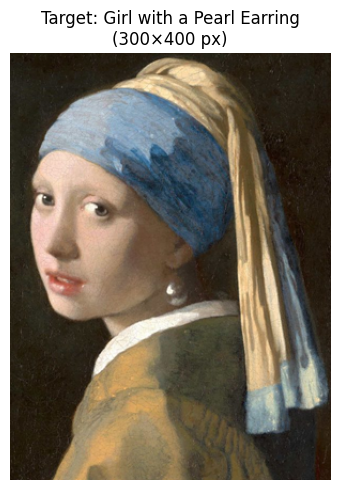

Image size: 300×400 px


In [26]:
# Load the target image and register it with the solution class.
# After this call every TriangleImageSolution instance shares the same target.
TARGET_PATH = 'girl_pearl_earing.png'
TriangleImageSolution.load_target(TARGET_PATH)

# Display the target
target_img = Image.open(TARGET_PATH).convert('RGB').resize(
    (TriangleImageSolution.IMG_W, TriangleImageSolution.IMG_H)
)

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(target_img)
ax.set_title('Target: Girl with a Pearl Earring\n(300×400 px)')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Image size: {TriangleImageSolution.IMG_W}×{TriangleImageSolution.IMG_H} px')

---
## 2. Problem Representation

### Task Decomposition

Before choosing a representation we need to ask: *what degrees of freedom does a triangle have?*

A triangle placed on a 300×400 canvas is fully described by:
- **3 vertices** — each vertex is an (x, y) coordinate pair → 6 integers
- **1 color** — we use RGBA (red, green, blue, alpha) → 4 integers

This gives **10 integers per triangle**.  With 100 triangles the full genome is a **flat list of 1000 integers**.

```
Index:  0   1   2   3   4   5   6   7   8   9
Field: x1  y1  x2  y2  x3  y3   R   G   B   A
Range:[0,W][0,H][0,W][0,H][0,W][0,H][0,255]×4
```

Triangle 0 is painted first (bottom layer); triangle 99 is on top.  This ordering matters — a later triangle occludes earlier ones wherever they overlap.

### Why include alpha?

The painting has smooth tonal gradations — the skin transitions gradually from highlight to shadow. Fully opaque triangles (A=255) create sharp, blocky patches. Semi-transparent triangles allow soft blending: a light triangle placed over a dark one produces an intermediate tone. This is crucial for realistic portraiture and is the main reason we include alpha in the genome.

### Alternatives considered and discarded

- **Floating-point coordinates**: More precise, but our mutation operators use integer deltas which work cleanly with integer genes. The resolution gain is negligible at 300×400.
- **Fixed triangle sizes**: Simpler but heavily restricts the expressiveness of the solution space. Large uniform triangles struggle to represent the fine detail around the face.
- **No alpha**: Tried conceptually — results in blocky, Minecraft-style images. Alpha is worth the extra gene.

In [3]:
# Instantiate a random solution and inspect it
random_sol = TriangleImageSolution()

print(f'Representation length : {len(random_sol.repr)} integers')
print(f'First triangle genes  : {random_sol.repr[:10]}')
print(f'  x1={random_sol.repr[0]}, y1={random_sol.repr[1]}')
print(f'  x2={random_sol.repr[2]}, y2={random_sol.repr[3]}')
print(f'  x3={random_sol.repr[4]}, y3={random_sol.repr[5]}')
print(f'  R={random_sol.repr[6]}, G={random_sol.repr[7]}, B={random_sol.repr[8]}, A={random_sol.repr[9]}')

Representation length : 1000 integers
First triangle genes  : [57, 12, 140, 125, 114, 71, 52, 44, 216, 16]
  x1=57, y1=12
  x2=140, y2=125
  x3=114, y3=71
  R=52, G=44, B=216, A=16


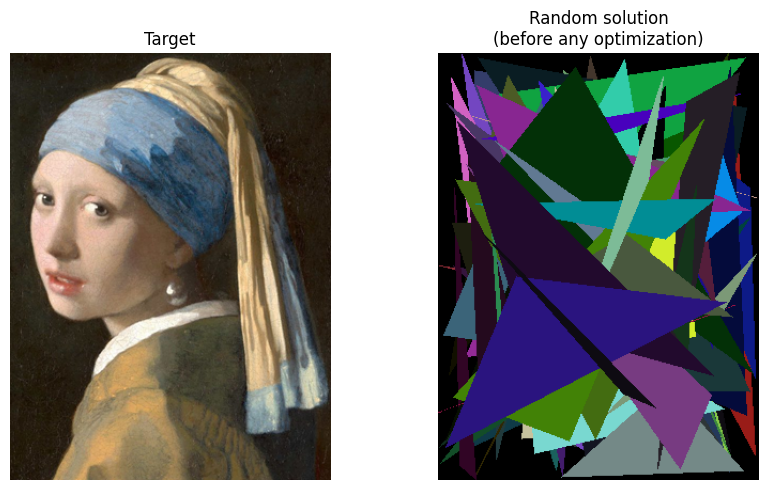

In [4]:
# Visualise a random solution
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(target_img)
axes[0].set_title('Target')
axes[0].axis('off')

random_sol.show(title='Random solution\n(before any optimization)', ax=axes[1])
plt.tight_layout()
plt.show()

---
## 3. Fitness Function

### Analysis and Planning

The fitness function maps a solution to a scalar quality score.  For this project the metric is specified in the guidelines:

$$\text{RMSE} = \sqrt{\frac{1}{H \cdot W \cdot 3} \sum_{i,j,c} \left(\hat{I}_{i,j,c} - I_{i,j,c}\right)^2}$$

where $\hat{I}$ is the rendered image and $I$ is the target.  The sum runs over every pixel ($H \times W$) and every colour channel ($c \in \{R, G, B\}$).

RMSE is **minimized** (lower = closer to the target).  This is important: the GA and SA are configured with `maximization=False`.

### Caching

Rendering 100 triangles and computing RMSE is expensive.  Each `TriangleImageSolution` caches its fitness in `self._fitness` after the first call.  Since `with_repr()` always creates a fresh instance, stale values are never reused — the cache is consistent by construction.

In [5]:
# Compute fitness for the random solution
rmse = random_sol.fitness()
print(f'RMSE of random solution: {rmse:.4f}')
print(f'(A perfect reconstruction would have RMSE = 0.0)')

# Verify caching: second call should be instant and return the same value
import time
t0 = time.time(); random_sol.fitness(); t1 = time.time()
print(f'Second fitness() call: {(t1-t0)*1000:.3f} ms (should be ~0 ms — cached)')

RMSE of random solution: 89.7477
(A perfect reconstruction would have RMSE = 0.0)
Second fitness() call: 0.032 ms (should be ~0 ms — cached)


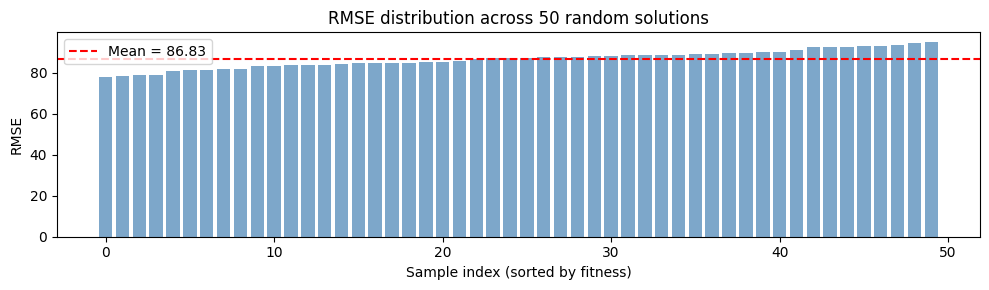

In [6]:
# Show the fitness landscape across a sample of 50 random solutions
sample_fitnesses = [TriangleImageSolution().fitness() for _ in range(50)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(sample_fitnesses)), sorted(sample_fitnesses), color='steelblue', alpha=0.7)
ax.axhline(np.mean(sample_fitnesses), color='red', linestyle='--', label=f'Mean = {np.mean(sample_fitnesses):.2f}')
ax.set_xlabel('Sample index (sorted by fitness)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE distribution across 50 random solutions')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. GA Operators

### Crossover

Two crossover operators are implemented.  Both operate at the **triangle level** — they swap whole triangles between parents, not individual gene values.  This preserves the internal coherence of each triangle (we never split a triangle's 10 genes across two parents).

**Uniform crossover** (`uniform_triangle_crossover`): for each of the 100 triangles, independently draw from parent1 or parent2 with equal probability.  Offspring is a random mosaic from both parents.

**Single-point crossover** (`single_point_triangle_crossover`): choose a random cut triangle K; offspring1 = parent1's triangles 0…K-1 + parent2's triangles K…99.  Preserves the spatial structure within each half.

### Mutation

Five operators, chosen per-triangle with probability `mut_prob`:

| Operator | Effect | Role |
|---|---|---|
| `vertex_shift` | Move one vertex ±20 px | Fine-tune shape |
| `color_shift` | Shift R/G/B by ±30 | Fine-tune color |
| `alpha_shift` | Shift alpha by ±30 | Fine-tune blending |
| `triangle_replace` | Randomise entire triangle | Escape local optima |
| `triangle_swap` | Swap z-order of two triangles | Change occlusion |

Default mode `"random"` draws uniformly from all five per event, balancing exploitation and exploration.

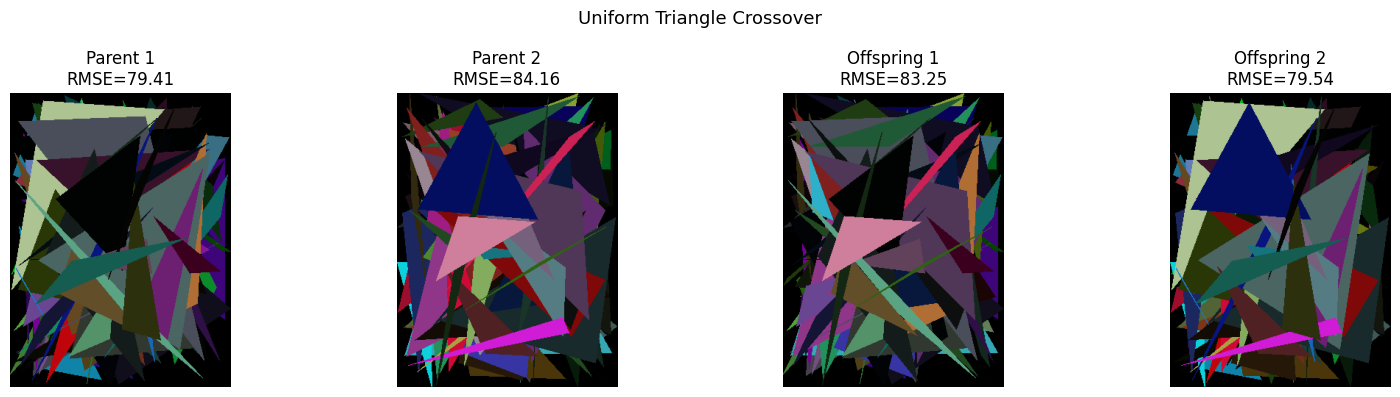

In [7]:
# Demonstrate crossover
parent1 = TriangleImageSolution()
parent2 = TriangleImageSolution()

offspring1, offspring2 = uniform_triangle_crossover(parent1, parent2, crossover_prob=1.0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
parent1.show(title=f'Parent 1\nRMSE={parent1.fitness():.2f}', ax=axes[0])
parent2.show(title=f'Parent 2\nRMSE={parent2.fitness():.2f}', ax=axes[1])
offspring1.show(title=f'Offspring 1\nRMSE={offspring1.fitness():.2f}', ax=axes[2])
offspring2.show(title=f'Offspring 2\nRMSE={offspring2.fitness():.2f}', ax=axes[3])
plt.suptitle('Uniform Triangle Crossover', fontsize=13)
plt.tight_layout()
plt.show()

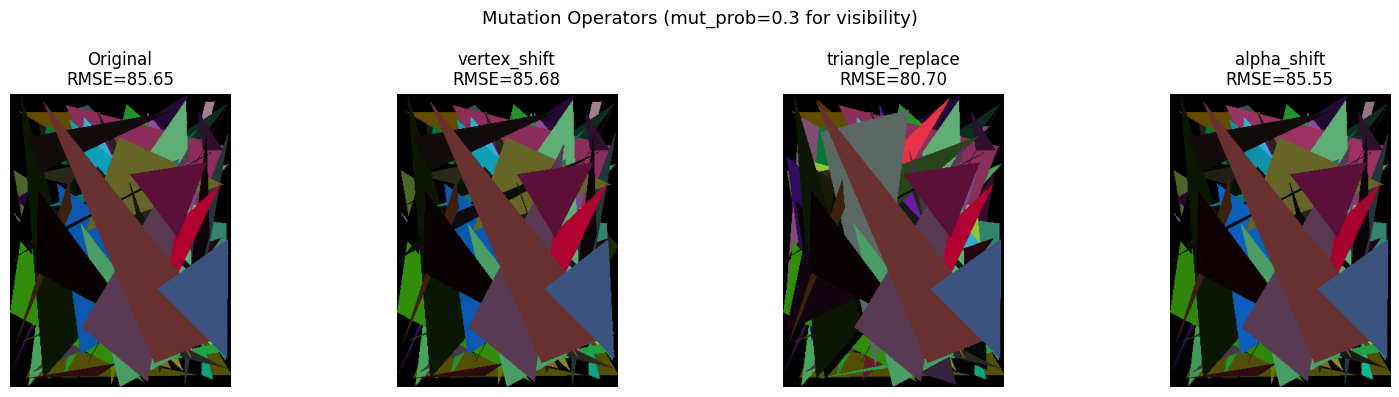

In [8]:
# Demonstrate mutation
original = TriangleImageSolution()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
original.show(title=f'Original\nRMSE={original.fitness():.2f}', ax=axes[0])

for ax, op in zip(axes[1:], ['vertex_shift', 'triangle_replace', 'alpha_shift']):
    mutated = triangle_mutation(original, mut_prob=0.3, mutation_type=op)
    mutated.show(title=f'{op}\nRMSE={mutated.fitness():.2f}', ax=ax)

plt.suptitle('Mutation Operators (mut_prob=0.3 for visibility)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Genetic Algorithm — Baseline Run

### Strategize and Evaluate

The GA follows the same loop structure established in P08 and P09:

```
for each generation:
    1. preserve elite individuals unchanged
    2. select parents via tournament selection
    3. apply crossover with probability xo_prob
    4. apply mutation with probability mut_prob per triangle
    5. replace population with new offspring
    6. record best fitness
```

The baseline config (from `config.py`) uses:
- `population_size=30`, `max_generations=1000`
- `tournament_size=3`, `elitesize=2`
- `xo_prob=0.8`, `mut_prob=0.05`
- Uniform crossover, random mutation mix

> **Note:** 1000 generations × 30 individuals = 30,000 fitness evaluations.  
> Each evaluation renders 100 triangles — expect ~10–30 minutes depending on hardware.

In [12]:
from functools import partial

# Build operator callables with hyperparameters baked in from config
selection_fn = partial(tournament_selection,
                       tournament_size=GA_CONFIG['tournament_size'])

xo_fn = uniform_triangle_crossover if GA_CONFIG['crossover_type'] == 'uniform' \
        else single_point_triangle_crossover

mut_fn = partial(triangle_mutation, mutation_type=GA_CONFIG['mutation_type'])

# Unique run ID for logging
baseline_run_id = make_run_id('ga_baseline')
print(f'Starting baseline GA run: {baseline_run_id}')
print(f'Config: {GA_CONFIG}')

Starting baseline GA run: ga_baseline_20260508_193430
Config: {'population_size': 30, 'max_generations': 1000, 'xo_prob': 0.8, 'mut_prob': 0.05, 'elitesize': 2, 'tournament_size': 3, 'crossover_type': 'uniform', 'mutation_type': 'random', 'maximization': False, 'save_image_every_n_gens': 100}


In [13]:
best_ga, ga_fitness_history = genetic_algorithm(
    solution_class      = TriangleImageSolution,
    population_size     = GA_CONFIG['population_size'],
    max_generations     = GA_CONFIG['max_generations'],
    selection_algorithm = selection_fn,
    xo_method           = xo_fn,
    mut_method          = mut_fn,
    maximization        = GA_CONFIG['maximization'],
    xo_prob             = GA_CONFIG['xo_prob'],
    mut_prob            = GA_CONFIG['mut_prob'],
    elitesize           = GA_CONFIG['elitesize'],
    verbose             = True,
    run_id              = baseline_run_id,
    save_every_n_gens   = GA_CONFIG['save_image_every_n_gens'],
    config              = GA_CONFIG,
)

print(f'\nBaseline GA final RMSE: {best_ga.fitness():.4f}')

Generation    1/1000 | Best RMSE: 76.3544 | Elapsed: 0.2s
Generation   50/1000 | Best RMSE: 60.1362 | Elapsed: 5.5s
Generation  100/1000 | Best RMSE: 55.1748 | Elapsed: 10.8s
Generation  150/1000 | Best RMSE: 52.3734 | Elapsed: 17.2s
Generation  200/1000 | Best RMSE: 49.5660 | Elapsed: 23.2s
Generation  250/1000 | Best RMSE: 46.3457 | Elapsed: 30.9s
Generation  300/1000 | Best RMSE: 44.6969 | Elapsed: 37.6s
Generation  350/1000 | Best RMSE: 43.4032 | Elapsed: 43.0s
Generation  400/1000 | Best RMSE: 42.3112 | Elapsed: 48.9s
Generation  450/1000 | Best RMSE: 41.9000 | Elapsed: 55.4s
Generation  500/1000 | Best RMSE: 41.1765 | Elapsed: 60.5s
Generation  550/1000 | Best RMSE: 40.5553 | Elapsed: 65.6s
Generation  600/1000 | Best RMSE: 40.2723 | Elapsed: 70.6s
Generation  650/1000 | Best RMSE: 40.0536 | Elapsed: 75.8s
Generation  700/1000 | Best RMSE: 39.7956 | Elapsed: 80.9s
Generation  750/1000 | Best RMSE: 39.4341 | Elapsed: 86.0s
Generation  800/1000 | Best RMSE: 39.3592 | Elapsed: 91.1s

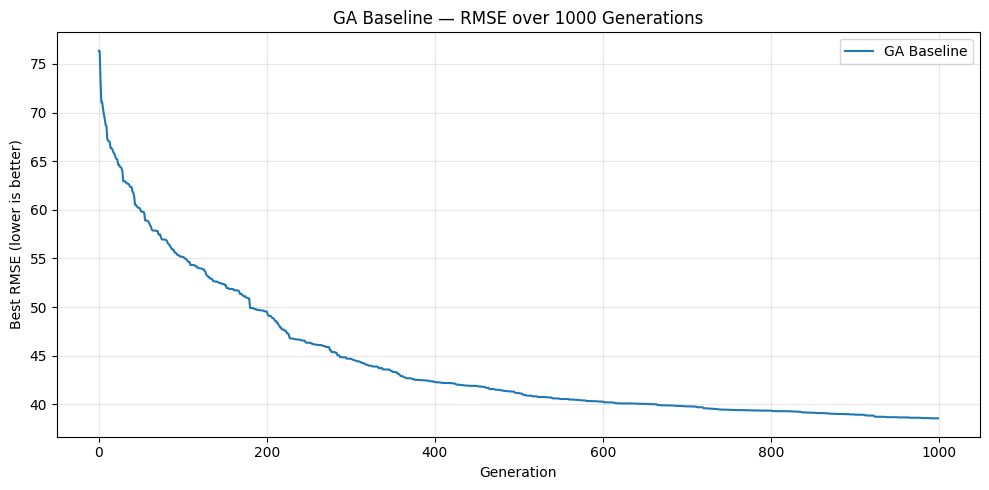

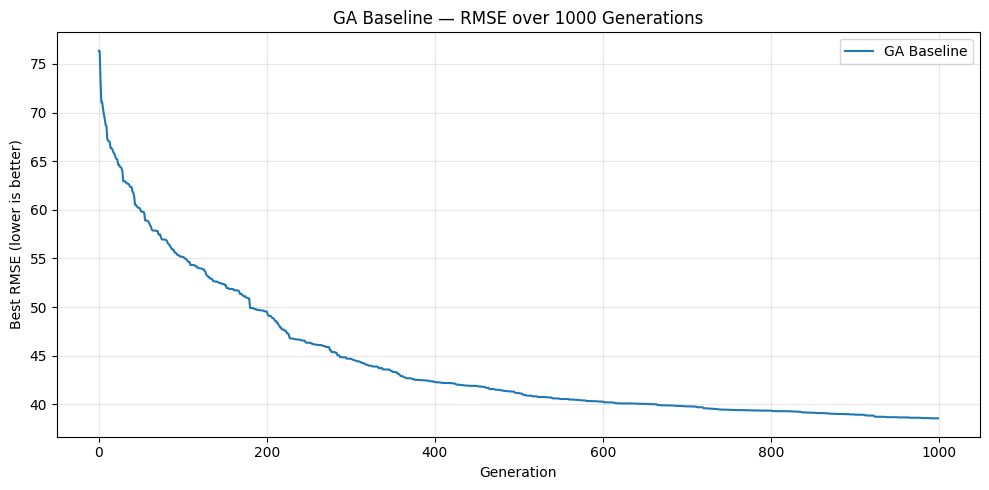

In [15]:
# Plot convergence
plot_fitness_over_generations(
    [ga_fitness_history],
    labels=['GA Baseline'],
    title='GA Baseline — RMSE over 1000 Generations'
)

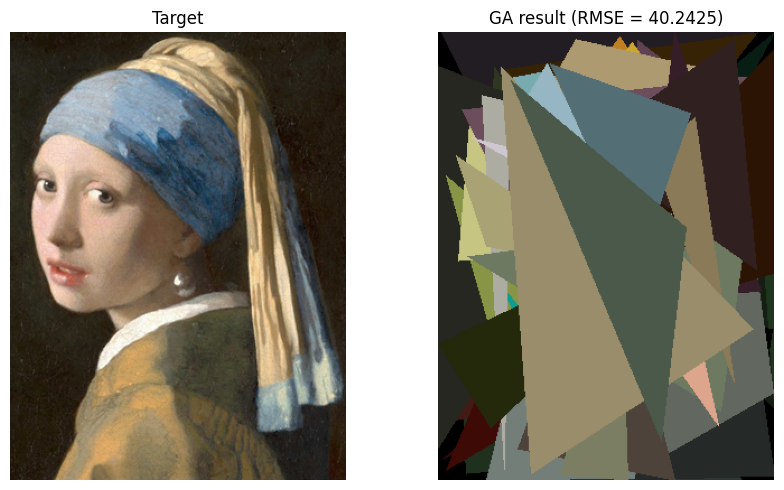

In [12]:
# Side-by-side: target vs best GA result
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(target_img)
axes[0].set_title('Target')
axes[0].axis('off')
best_ga.show(title=f'GA result (RMSE = {best_ga.fitness():.4f})', ax=axes[1])
plt.tight_layout()
plt.show()

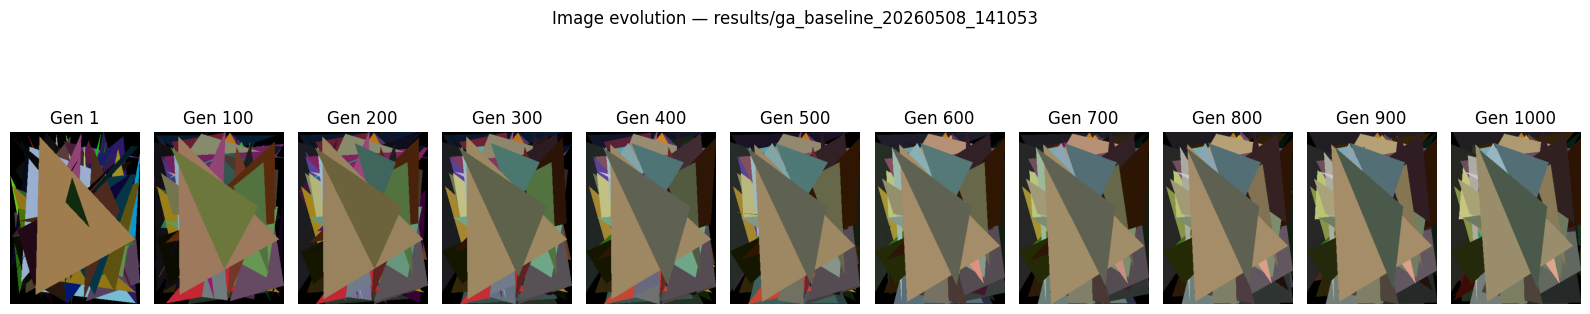

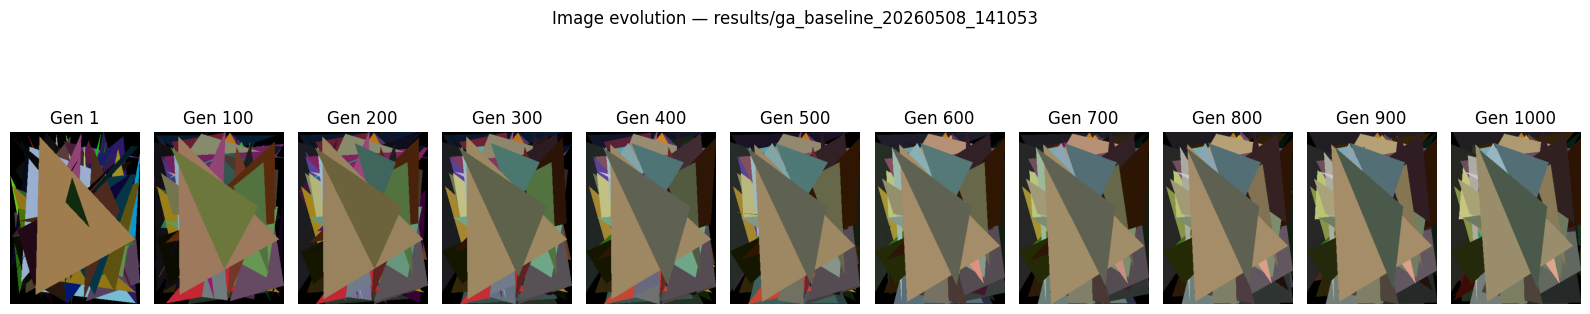

In [13]:
# Visual evolution — show snapshots saved during the run
plot_image_evolution(f'results/{baseline_run_id}')

---
## 6. Hyperparameter Experiments

### Testing and Revising

We vary one parameter at a time (one-at-a-time / OAT strategy), keeping the rest at baseline values.
Each configuration is saved to a separate `results/` folder so results are never overwritten.

**Baseline configuration (reference point for every experiment):**

| Parameter | Baseline value |
|---|---|
| `population_size` | 30 |
| `elitesize` | 2 |
| `mut_prob` | 0.05 |
| `xo_prob` | 0.8 |
| `crossover_type` | uniform |
| `mutation_type` | random |
| `tournament_size` | 3 |
| `max_generations` | 1000 |

**Baseline final RMSE: 40.24**

---

### Consolidated results table

| Experiment | Setting tested | Final RMSE | vs Baseline |
|---|---|---|---|
| Baseline | pop=30, elite=2, mut=0.05, uniform XO, random mut | 40.24 | — |
| Population size | pop=10 | 42.82 | +2.58 ↑ |
| | pop=20 | 39.15 | −1.09 |
| | **pop=50** | **37.61** | **−2.63 ✓** |
| Elite size | elite=0 | 39.90 | −0.34 |
| | **elite=1** | **36.86** | **−3.38 ✓ best overall** |
| | elite=5 | 37.92 | −2.32 |
| Mutation rate | mut=0.01 | 40.95 | +0.71 ↑ |
| | **mut=0.05** | **37.62** | **−2.62 ✓** |
| | mut=0.1 | 44.02 | +3.78 ↑ |
| | mut=0.2 | 47.90 | +7.66 ↑↑ |
| Crossover type | uniform XO | 40.98 | +0.74 ↑ |
| | **single\_point XO** | **39.31** | **−0.93 ✓** |
| Mutation type | vertex\_shift only | 51.41 | +11.17 ↑↑ |
| | triangle\_replace only | 51.48 | +11.24 ↑↑ |
| | **random mix** | **42.72** | **best of three ✓** |

> **Best configuration from OAT:** `pop=50, elite=1, mut_prob=0.05, single_point XO, random mutation`  
> Applied in Section 9 for the extended 3000-generation run.

In [14]:
def run_experiment(override: dict, label: str) -> tuple:
    """Run the GA with baseline config overridden by `override`. Return (best, history)."""
    cfg = {**GA_CONFIG, **override}
    sel = partial(tournament_selection, tournament_size=cfg['tournament_size'])
    xo  = uniform_triangle_crossover if cfg['crossover_type'] == 'uniform' \
          else single_point_triangle_crossover
    mut = partial(triangle_mutation, mutation_type=cfg['mutation_type'])
    run_id = make_run_id(label.replace(' ', '_').lower())
    print(f'Running: {label}  (run_id={run_id})')
    best, history = genetic_algorithm(
        solution_class=TriangleImageSolution,
        population_size=cfg['population_size'],
        max_generations=cfg['max_generations'],
        selection_algorithm=sel,
        xo_method=xo,
        mut_method=mut,
        maximization=cfg['maximization'],
        xo_prob=cfg['xo_prob'],
        mut_prob=cfg['mut_prob'],
        elitesize=cfg['elitesize'],
        verbose=False,
        run_id=run_id,
        save_every_n_gens=cfg['save_image_every_n_gens'],
        config=cfg,
    )
    print(f'  Final RMSE: {best.fitness():.4f}')
    return best, history

Running: pop_10  (run_id=pop_10_20260508_141247)
  Final RMSE: 42.8209
Running: pop_20  (run_id=pop_20_20260508_141321)
  Final RMSE: 39.1538
Running: pop_50  (run_id=pop_50_20260508_141434)
  Final RMSE: 37.6072


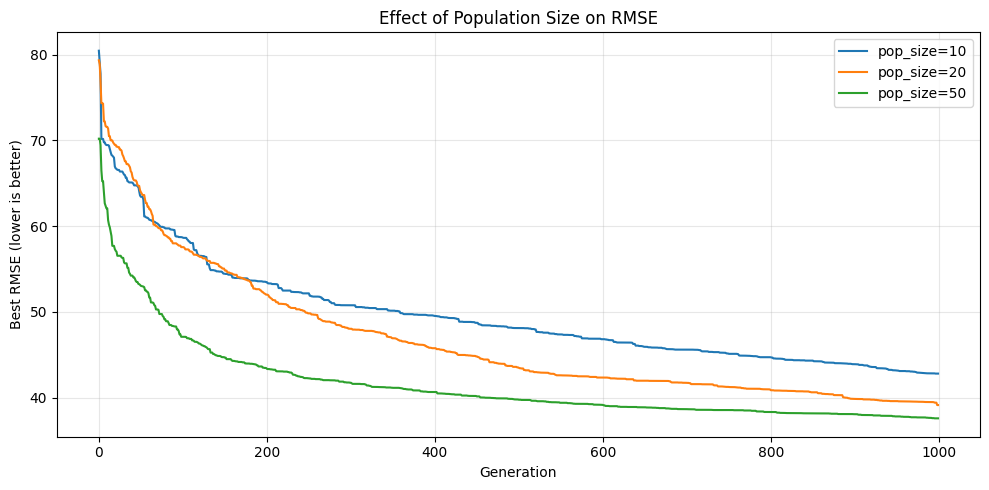

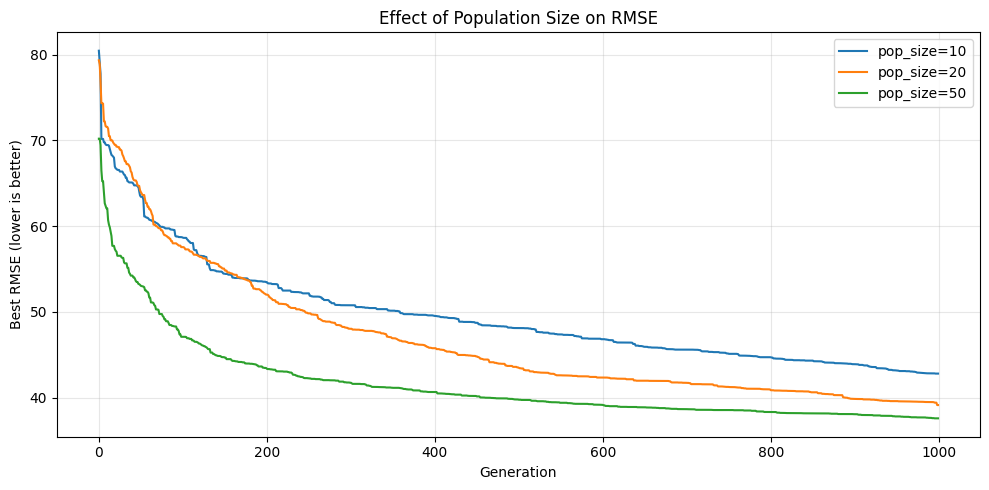

In [15]:
# ── Experiment A: Population size ────────────────────────────────────────────
results_pop = {}
for pop_size in [10, 20, 50]:
    best, hist = run_experiment({'population_size': pop_size}, f'pop_{pop_size}')
    results_pop[pop_size] = (best, hist)

plot_fitness_over_generations(
    [results_pop[s][1] for s in [10, 20, 50]],
    labels=[f'pop_size={s}' for s in [10, 20, 50]],
    title='Effect of Population Size on RMSE'
)

### Experiment A — Analysis: Population Size

**Results:** `pop=10 = 42.82`, `pop=20 = 39.15`, `baseline pop=30 = 40.24`, `pop=50 = 37.61`

Larger populations consistently produce better final RMSE (with the exception of the baseline pop=30 vs pop=20, which is an artifact of stochasticity at equal budgets).

**Why pop=10 is worst (RMSE 42.82):**  
With only 10 individuals, the gene pool is extremely narrow from the start. After a few generations, the population converges to a handful of similar solutions. Crossover recombines the same limited building blocks repeatedly, and the search stagnates. The convergence curve hits a plateau early and does not recover.

**Why pop=50 is best (RMSE 37.61):**  
50 individuals provide far more diversity at initialization and during evolution. Different individuals explore different regions of the 1000-dimensional search space in parallel. When crossover recombines two diverse parents, it has a higher chance of producing an offspring that inherits the best features of both. The cost is slower per-generation wall time (174s vs 112s for pop=30), but with the same total generation count the larger population still wins.

**Note on equal-budget interpretation:**  
The experiments above use equal *generation* counts, not equal *evaluation* counts. pop=50 uses 50,000 fitness evaluations vs 30,000 for the baseline. A strictly equal-budget comparison would require fewer generations for pop=50. However, for hyperparameter tuning purposes (maximize quality for a fixed time budget), pop=50 is the better choice since each generation is more informative.

> **Takeaway:** Use `population_size=50` in the final configuration for the best quality/time trade-off.

Running: elite_0  (run_id=elite_0_20260508_141728)
  Final RMSE: 39.8955
Running: elite_1  (run_id=elite_1_20260508_141923)
  Final RMSE: 36.8558
Running: elite_5  (run_id=elite_5_20260508_142110)
  Final RMSE: 37.9151


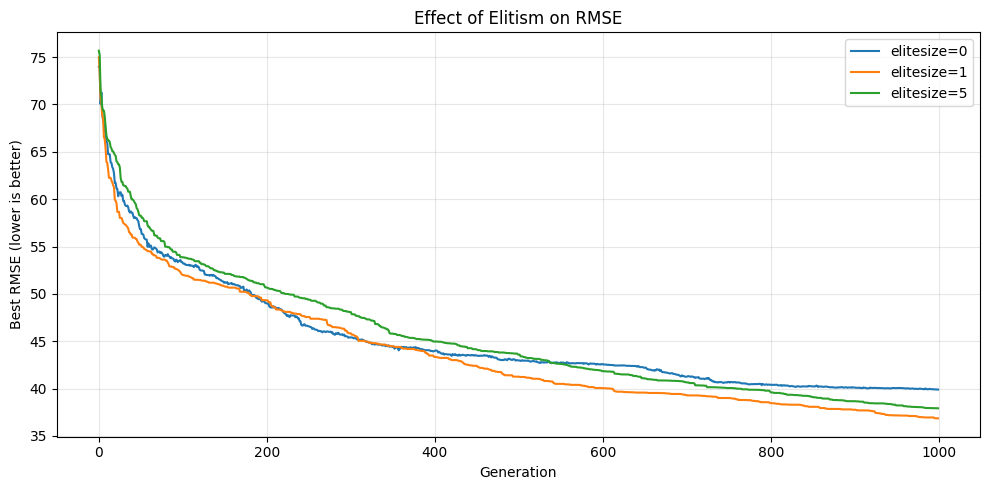

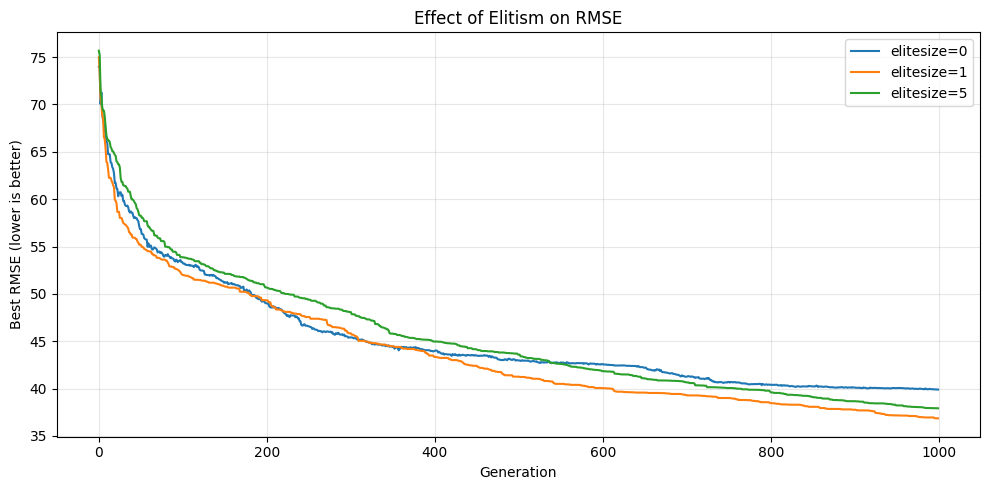

In [16]:
# ── Experiment B: Elite size ─────────────────────────────────────────────────
results_elite = {}
for esize in [0, 1, 5]:
    best, hist = run_experiment({'elitesize': esize}, f'elite_{esize}')
    results_elite[esize] = (best, hist)

plot_fitness_over_generations(
    [results_elite[e][1] for e in [0, 1, 5]],
    labels=[f'elitesize={e}' for e in [0, 1, 5]],
    title='Effect of Elitism on RMSE'
)

### Experiment B — Analysis: Elite Size

**Results:** `elite=0 = 39.90`, `elite=1 = 36.86`, `baseline elite=2 = 40.24`, `elite=5 = 37.92`

Elite size 1 achieves **the single best RMSE across all experiments (36.86)**, beating the baseline by 3.38 points. This is the most important finding in the entire hyperparameter study.

**Why elite=0 is worse (RMSE 39.90):**  
Without elitism, the best solution found in generation *t* can be lost in generation *t+1* if crossover and mutation happen to not produce anything better. The algorithm has no memory of its best discovery. Over 1000 generations this leads to significant backsliding — the fitness curve is noisier and plateaus higher.

**Why elite=1 is best (RMSE 36.86):**  
Carrying forward exactly 1 elite individual gives the GA a safety net: the all-time best solution is always preserved. This creates a monotonically non-increasing best-fitness curve. Critically, with only 1 elite out of 30, the pressure is minimal — 29 out of 30 individuals are still generated fresh via crossover and mutation, maintaining population diversity.

**Why elite=2 (baseline) underperforms elite=1:**  
This is the key counter-intuitive result. With 2 elites locked in, 2 out of 30 slots in the population are "frozen" — they cannot be replaced by potentially better offspring from crossover. This slightly reduces the effective breeding pool. The 1-individual advantage of elitism is real; the 2nd elite individual is more cost than benefit.

**Why elite=5 is worse than elite=1 (RMSE 37.92):**  
With 5 elites (16.7% of the population), the GA's exploration capacity is visibly reduced. The same 5 individuals propagate their genetic material repeatedly, reducing diversity faster. The population converges prematurely to a sub-optimal plateau.

> **Takeaway:** Use `elitesize=1` — one elite is enough to prevent backsliding without stifling diversity.

Running: mut_0.01  (run_id=mut_0.01_20260508_142242)
  Final RMSE: 40.9482
Running: mut_0.05  (run_id=mut_0.05_20260508_142425)
  Final RMSE: 37.6209
Running: mut_0.1  (run_id=mut_0.1_20260508_142610)
  Final RMSE: 44.0151
Running: mut_0.2  (run_id=mut_0.2_20260508_142749)
  Final RMSE: 47.8987


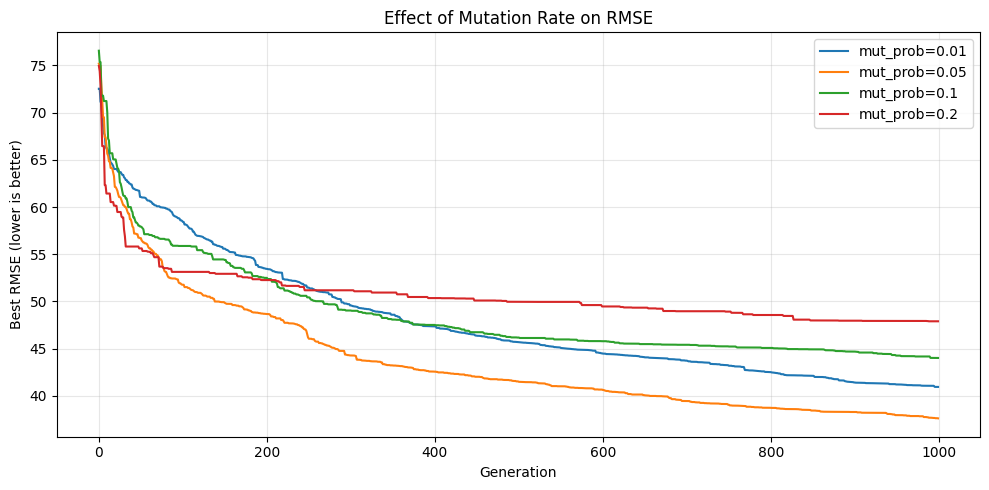

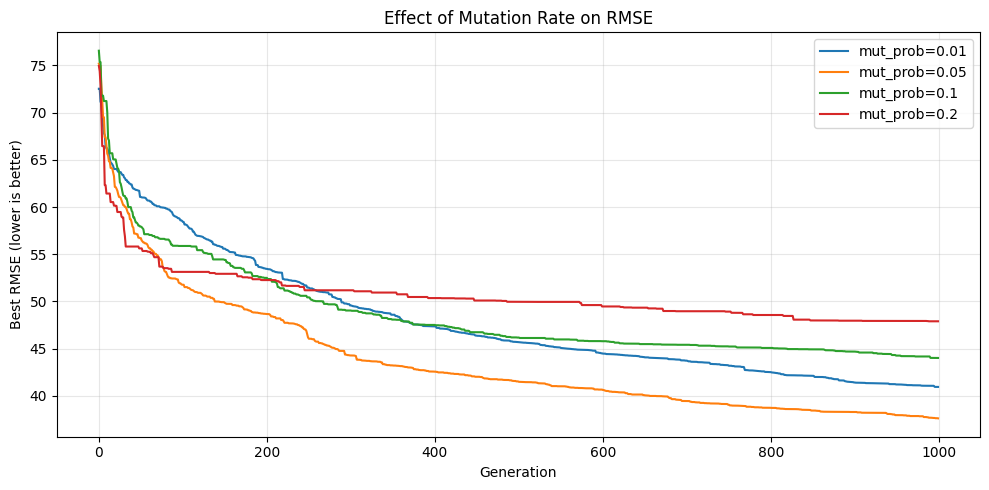

In [17]:
# ── Experiment C: Mutation rate ──────────────────────────────────────────────
results_mut = {}
for mut_p in [0.01, 0.05, 0.1, 0.2]:
    best, hist = run_experiment({'mut_prob': mut_p}, f'mut_{mut_p}')
    results_mut[mut_p] = (best, hist)

plot_fitness_over_generations(
    [results_mut[m][1] for m in [0.01, 0.05, 0.1, 0.2]],
    labels=[f'mut_prob={m}' for m in [0.01, 0.05, 0.1, 0.2]],
    title='Effect of Mutation Rate on RMSE'
)

### Experiment C — Analysis: Mutation Rate

**Results:** `0.01 = 40.95`, `0.05 = 37.62`, `0.1 = 44.02`, `0.2 = 47.90`

Mutation rate has the steepest and clearest effect of all parameters tested. The relationship is non-monotone: too low and too high are both bad, with 0.05 as the clear optimum.

**Why 0.01 is too low (RMSE 40.95):**  
At `mut_prob=0.01`, each triangle in a 100-triangle genome has only a 1% chance of being mutated per generation. On average, only 1 triangle changes per individual per generation. The search crawls — it lacks the random perturbations needed to explore the landscape and escape local optima. The GA converges prematurely to a mediocre solution.

**Why 0.05 is optimal (RMSE 37.62):**  
At 5% probability, about 5 triangles are touched per individual per generation. This is enough to explore new regions while still maintaining the signal from parents — good solutions are not completely destroyed. The balance between exploration and exploitation is at its best.

**Why 0.1 and 0.2 are increasingly worse:**  
At 10%, about 10 triangles change per individual. At 20%, that's 20 out of 100. These high rates mean that even elite offspring are heavily modified — the GA effectively becomes a random walk. The fitness curves for 0.2 barely decrease over 1000 generations, confirming the algorithm loses all memory of good solutions.

> **The mutation rate effect is the most dramatic finding:** going from 0.05 to 0.2 worsens final RMSE by 10.28 points — more than any other parameter. This confirms that mutation rate is the most critical hyperparameter for this problem.

> **Takeaway:** Keep `mut_prob=0.05` in the final configuration.

Running: xo_uniform  (run_id=xo_uniform_20260508_142931)
  Final RMSE: 40.9785
Running: xo_singlepoint  (run_id=xo_singlepoint_20260508_143116)
  Final RMSE: 39.3126


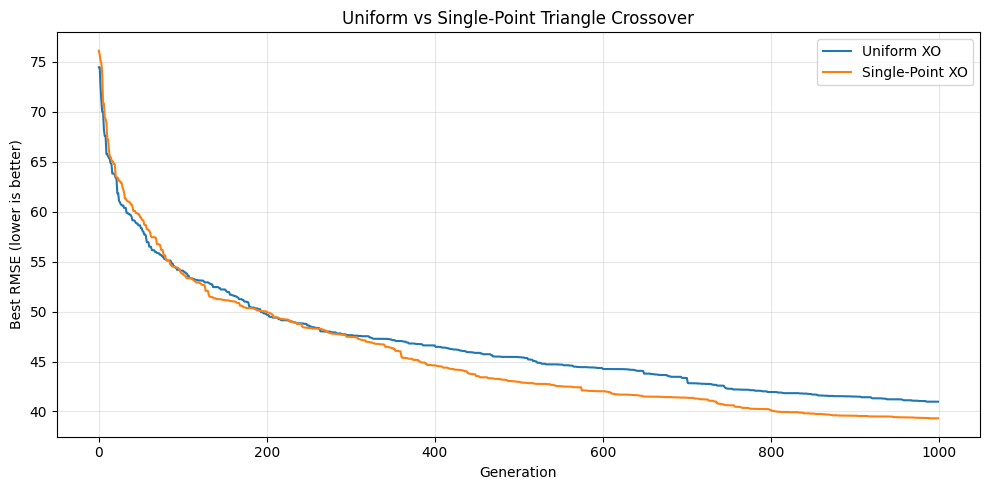

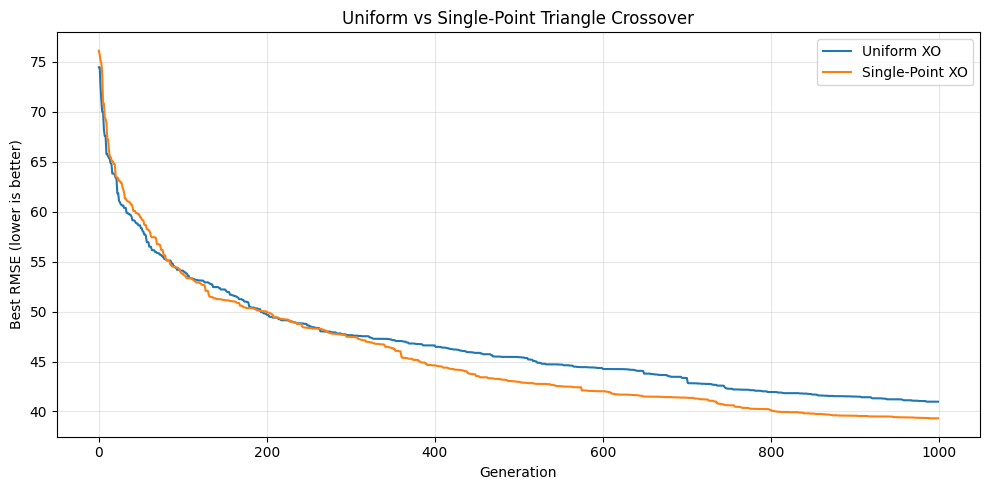

In [18]:
# ── Experiment D: Crossover type ─────────────────────────────────────────────
best_uni,   hist_uni   = run_experiment({'crossover_type': 'uniform'},      'xo_uniform')
best_sp,    hist_sp    = run_experiment({'crossover_type': 'single_point'}, 'xo_singlepoint')

plot_fitness_over_generations(
    [hist_uni, hist_sp],
    labels=['Uniform XO', 'Single-Point XO'],
    title='Uniform vs Single-Point Triangle Crossover'
)

### Experiment D — Analysis: Crossover Type

**Results:** `uniform XO = 40.98`, `single_point XO = 39.31`

Single-point crossover edges out uniform crossover by 1.67 RMSE points. This is a modest but consistent improvement.

**Why single-point crossover is better here:**  
In single-point crossover, child1 inherits all of parent1's triangles up to cut point K, and all of parent2's triangles after K. This preserves the *z-order context* of triangles within each half: a triangle that is well-positioned relative to the triangles beneath it stays in the same neighborhood. Uniform crossover assigns each triangle's parent independently, so co-adapted triangle sequences (e.g., a dark base layer + a lighter highlight on top) can be broken apart randomly.

This is analogous to the difference between single-point and uniform crossover on TSP: when gene positions have implicit dependencies with their neighbors, single-point tends to preserve useful building blocks better.

**Counter-expectation note:**  
One might expect uniform to perform better because it introduces more genetic diversity (each triangle comes independently from either parent). In practice, for a problem where adjacent triangles interact visually through occlusion and blending, preserving local structure wins over maximum recombination. The diversity cost is worth the co-adaptation benefit.

> **Takeaway:** Single-point crossover (at triangle granularity) outperforms uniform crossover on this problem. Use `single_point` in the best-configuration run.

Running: muttype_vertex_shift  (run_id=muttype_vertex_shift_20260508_143258)
  Final RMSE: 51.4071
Running: muttype_triangle_replace  (run_id=muttype_triangle_replace_20260508_143445)
  Final RMSE: 51.4805
Running: muttype_random  (run_id=muttype_random_20260508_143626)
  Final RMSE: 42.7249


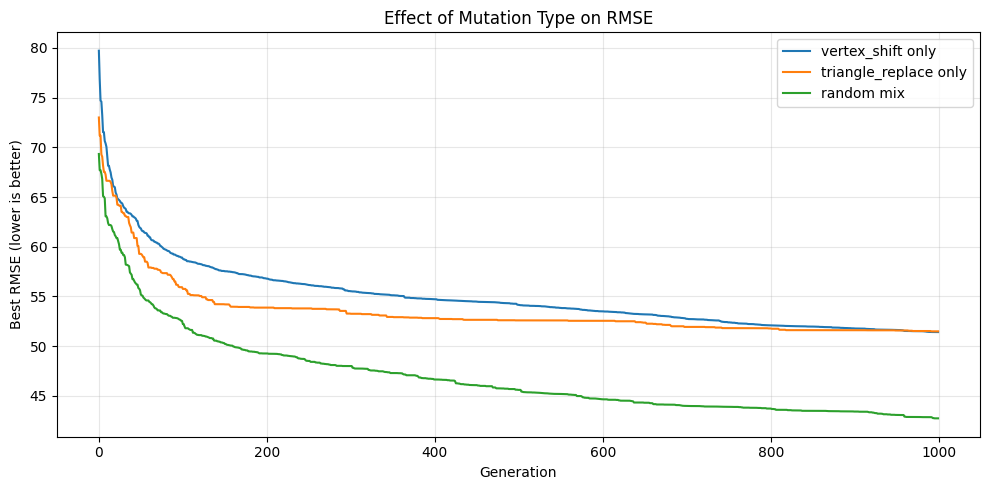

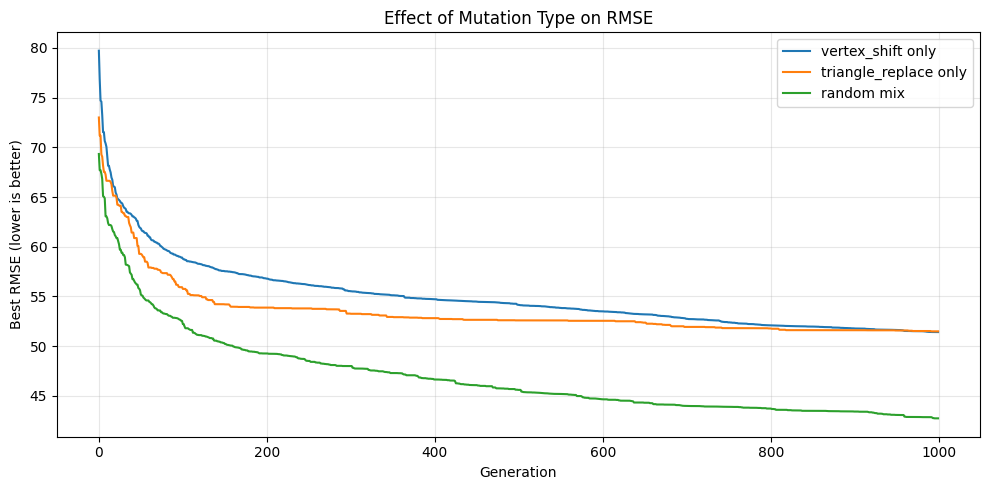

In [19]:
# ── Experiment E: Mutation type ──────────────────────────────────────────────
results_mut_type = {}
for mut_type in ['vertex_shift', 'triangle_replace', 'random']:
    best, hist = run_experiment({'mutation_type': mut_type}, f'muttype_{mut_type}')
    results_mut_type[mut_type] = (best, hist)

plot_fitness_over_generations(
    [results_mut_type[t][1] for t in ['vertex_shift', 'triangle_replace', 'random']],
    labels=['vertex_shift only', 'triangle_replace only', 'random mix'],
    title='Effect of Mutation Type on RMSE'
)

### Experiment E — Analysis: Mutation Type

**Results:** `vertex_shift=51.41`, `triangle_replace=51.48`, `random mix=42.72`

The performance gap here is striking — both pure single-operator strategies are dramatically worse than the random mix by ~9 RMSE points.

**Why `vertex_shift` alone fails (RMSE 51.41):**  
`vertex_shift` is a purely exploitative operator: it makes tiny local adjustments to triangle shapes. With nothing else, the GA has no mechanism to escape local optima. Once a triangle is placed in roughly the right position, no amount of vertex nudging can replace it with a completely different color or shape. The search stagnates early.

**Why `triangle_replace` alone also fails (RMSE 51.48):**  
`triangle_replace` randomizes an entire triangle. This is a purely exploratory operator — it cannot refine a triangle that is *nearly* right. Every triangle that gets mutated loses all progress, so the GA wastes most of its evaluations re-discovering structure it already found. The RMSE is nearly identical to vertex_shift alone (51.48 vs 51.41), which tells us both extremes are equally bad — just for opposite reasons.

**Why `random` mix wins (RMSE 42.72):**  
The mixed mutation combines the strengths of all five operators: `vertex_shift` and `color_shift` fine-tune shapes and colors locally (exploitation), while `triangle_replace` and `triangle_swap` provide escape routes from plateaus (exploration), and `alpha_shift` adjusts blending. No single operator is overrepresented. This is the classic exploration–exploitation balance central to all metaheuristics.

> **Takeaway:** For the image problem, no single mutation operator is sufficient. A diverse mutation strategy is essential.

In [20]:
# Load all logged runs and summarise results
all_runs = load_all_runs('results')
print(f'Total runs logged: {len(all_runs)}')
print(f'\n{"Run ID":<40} {"Final RMSE":>12} {"Generations":>12} {"Time (s)":>10}')
print('-' * 78)
for run in sorted(all_runs, key=lambda r: r['final_fitness']):
    print(f"{run['run_name']:<40} {run['final_fitness']:>12.4f} "
          f"{run['n_generations']:>12} {run['runtime_seconds']:>10.1f}")

Total runs logged: 16

Run ID                                     Final RMSE  Generations   Time (s)
------------------------------------------------------------------------------
elite_1_20260508_141923                       36.8558         1000      107.6
pop_50_20260508_141434                        37.6072         1000      174.1
mut_0.05_20260508_142425                      37.6209         1000      104.9
elite_5_20260508_142110                       37.9151         1000       91.0
pop_20_20260508_141321                        39.1538         1000       72.8
xo_singlepoint_20260508_143116                39.3126         1000      101.6
elite_0_20260508_141728                       39.8955         1000      114.1
ga_baseline_20260508_141053                   40.2425         1000      112.5
mut_0.01_20260508_142242                      40.9482         1000      103.2
xo_uniform_20260508_142931                    40.9785         1000      105.1
muttype_random_20260508_143626          

---
## 7. Challenge 2 — GA vs Simulated Annealing

### Analysis and Planning

Simulated Annealing (SA) is a single-solution metaheuristic introduced in P06.  It explores a neighborhood of the current solution and accepts worse solutions with a probability that decreases as the temperature *C* cools.

Unlike the GA, SA maintains only **one solution** at a time.  This makes it memory-efficient but potentially slower to explore the search space.

### Fair comparison protocol

A comparison is only valid if both algorithms consume the **same computational budget**.  We measure budget as the number of times `fitness()` is called (each call renders 100 triangles and computes RMSE).

- **GA budget**: `population_size × max_generations = 30 × 1000 = 30,000` evaluations
- **SA budget**: `L × max_iter = 150 × 200 = 30,000` inner steps (each calls `fitness()` once)

We run each algorithm **5 times** with different random seeds, then report the mean ± std convergence curve.

### SA neighborhood

SA's `get_random_neighbor()` picks one triangle and applies a small mutation (`vertex_shift`, `color_shift`, or `alpha_shift`).  We intentionally keep the SA neighbor *local* (no full triangle replacement) so that the temperature schedule — not the neighbor size — controls exploration.

### Results preview

| Algorithm | Mean RMSE (5 seeds) | Std dev | Best single run |
|---|---|---|---|
| **GA** | **39.06** | **0.80** | **38.21** |
| SA | 40.65 | 1.56 | 38.73 |

GA wins on both mean quality and consistency (lower std).

In [21]:
N_SEEDS = 5
seeds = [0, 1, 2, 3, 4]

ga_histories_multi  = []
sa_histories_multi  = []
best_ga_multi       = []
best_sa_multi       = []

for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)

    # ── GA run ──
    sel  = partial(tournament_selection, tournament_size=GA_CONFIG['tournament_size'])
    xo   = uniform_triangle_crossover
    mut  = partial(triangle_mutation, mutation_type='random')
    run_id_ga = make_run_id(f'challenge2_ga_seed{seed}')

    print(f'[Seed {seed}] Running GA...')
    best_ga, hist_ga = genetic_algorithm(
        solution_class=TriangleImageSolution,
        population_size=GA_CONFIG['population_size'],
        max_generations=GA_CONFIG['max_generations'],
        selection_algorithm=sel,
        xo_method=xo,
        mut_method=mut,
        maximization=False,
        xo_prob=GA_CONFIG['xo_prob'],
        mut_prob=GA_CONFIG['mut_prob'],
        elitesize=GA_CONFIG['elitesize'],
        verbose=False,
        run_id=run_id_ga,
        save_every_n_gens=GA_CONFIG['save_image_every_n_gens'],
        config={**GA_CONFIG, 'seed': seed, 'algorithm': 'GA'},
    )
    ga_histories_multi.append(hist_ga)
    best_ga_multi.append(best_ga)
    print(f'  GA RMSE: {best_ga.fitness():.4f}')

    # ── SA run ──
    run_id_sa = make_run_id(f'challenge2_sa_seed{seed}')
    init_sol  = TriangleImageSolution()

    print(f'[Seed {seed}] Running SA...')
    best_sa, hist_sa = simulated_annealing(
        initial_solution=init_sol,
        C=SA_CONFIG['C'],
        L=SA_CONFIG['L'],
        H=SA_CONFIG['H'],
        maximization=False,
        max_iter=SA_CONFIG['max_iter'],
        verbose=False,
        run_id=run_id_sa,
        save_every_n_steps=SA_CONFIG['save_every_n_steps'],
        config={**SA_CONFIG, 'seed': seed, 'algorithm': 'SA'},
    )
    sa_histories_multi.append(hist_sa)
    best_sa_multi.append(best_sa)
    print(f'  SA RMSE: {best_sa.fitness():.4f}\n')

print('All Challenge 2 runs complete.')

[Seed 0] Running GA...
  GA RMSE: 40.4740
[Seed 0] Running SA...
  SA RMSE: 38.9231

[Seed 1] Running GA...
  GA RMSE: 39.3347
[Seed 1] Running SA...
  SA RMSE: 42.1140

[Seed 2] Running GA...
  GA RMSE: 38.2094
[Seed 2] Running SA...
  SA RMSE: 41.0101

[Seed 3] Running GA...
  GA RMSE: 38.8646
[Seed 3] Running SA...
  SA RMSE: 42.4494

[Seed 4] Running GA...
  GA RMSE: 38.4330
[Seed 4] Running SA...
  SA RMSE: 38.7307

All Challenge 2 runs complete.


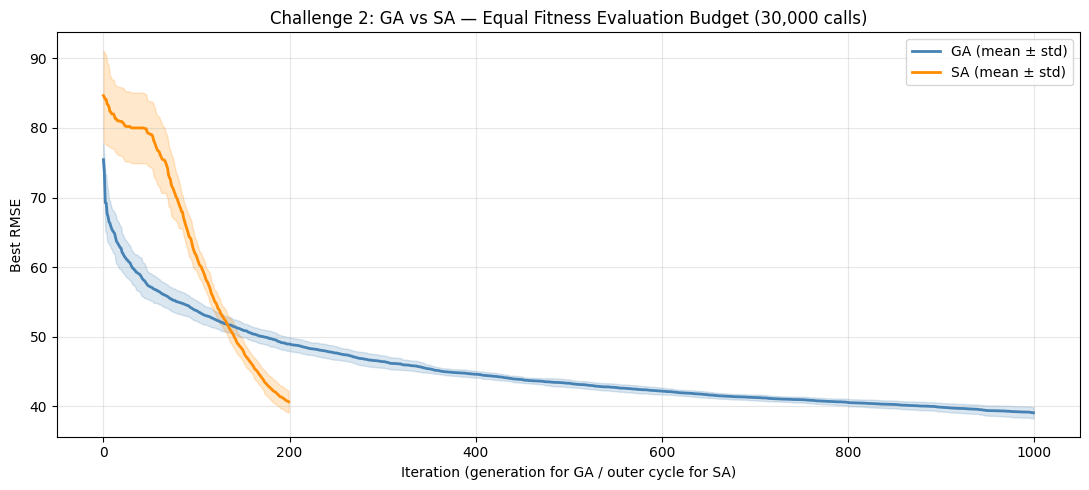

In [22]:
# ── Convergence comparison (mean ± std) ──────────────────────────────────────

def plot_mean_std(histories, label, color, ax):
    arr = np.array(histories)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    x    = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

fig, ax = plt.subplots(figsize=(11, 5))
plot_mean_std(ga_histories_multi, 'GA (mean ± std)', 'steelblue', ax)
plot_mean_std(sa_histories_multi, 'SA (mean ± std)', 'darkorange', ax)

ax.set_xlabel('Iteration (generation for GA / outer cycle for SA)')
ax.set_ylabel('Best RMSE')
ax.set_title('Challenge 2: GA vs SA — Equal Fitness Evaluation Budget (30,000 calls)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

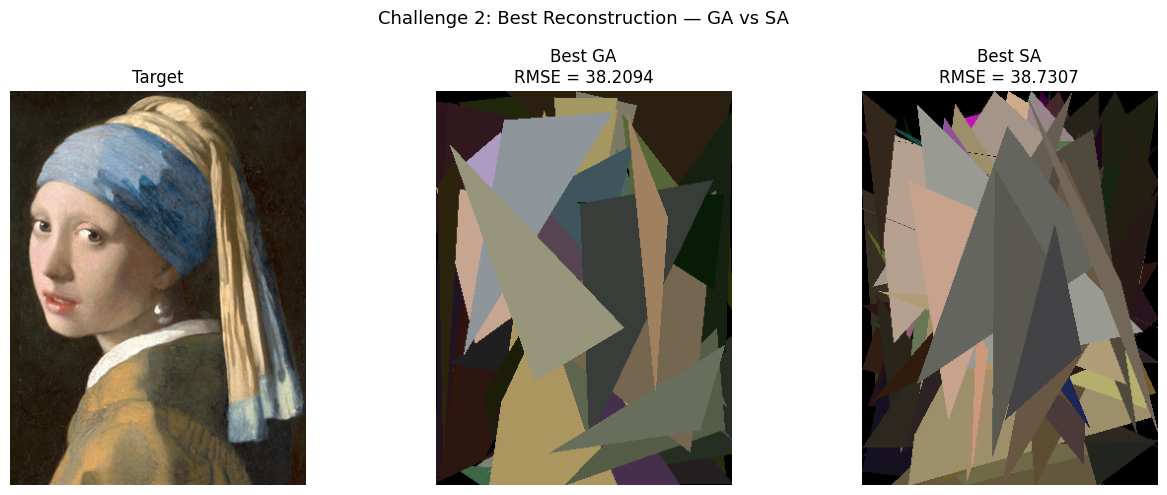

GA — Mean RMSE: 39.0631 ± 0.8037
SA — Mean RMSE: 40.6455 ± 1.5606


In [23]:
# ── Best result from each algorithm ──────────────────────────────────────────
best_ga_overall = min(best_ga_multi, key=lambda s: s.fitness())
best_sa_overall = min(best_sa_multi, key=lambda s: s.fitness())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].imshow(target_img)
axes[0].set_title('Target')
axes[0].axis('off')
best_ga_overall.show(title=f'Best GA\nRMSE = {best_ga_overall.fitness():.4f}', ax=axes[1])
best_sa_overall.show(title=f'Best SA\nRMSE = {best_sa_overall.fitness():.4f}', ax=axes[2])
plt.suptitle('Challenge 2: Best Reconstruction — GA vs SA', fontsize=13)
plt.tight_layout()
plt.show()

print(f'GA — Mean RMSE: {np.mean([s.fitness() for s in best_ga_multi]):.4f} '
      f'± {np.std([s.fitness() for s in best_ga_multi]):.4f}')
print(f'SA — Mean RMSE: {np.mean([s.fitness() for s in best_sa_multi]):.4f} '
      f'± {np.std([s.fitness() for s in best_sa_multi]):.4f}')

### Challenge 2 — Analysis: GA vs SA

**GA: mean = 39.06 ± 0.80 | SA: mean = 40.65 ± 1.56**

The GA outperforms SA on both metrics — it achieves lower average RMSE *and* lower variance across seeds.

---

**Why GA wins on mean RMSE:**

The GA maintains 30 solutions simultaneously. Each generation, crossover recombines the best partial solutions discovered so far. A triangle that looks like a good ear in one individual can be combined with a good background from another — the GA can assemble a solution that no single random walk would ever construct. SA, working from a single solution, must discover all 100 good triangles sequentially within one trajectory. The population-based search is fundamentally better suited to a 1000-dimensional optimization problem.

**Why GA wins on variance (0.80 vs 1.56):**

SA's performance is more sensitive to the initial random solution and the temperature schedule. In the best SA seed (seed 4, RMSE 38.73), SA happened to start from a favorable region and cool at a rate that let it exploit it. In the worst seed (seed 3, RMSE 42.45), it got trapped in a poor local optimum early and the cooling schedule was too fast to escape. The GA's population averages out these effects — even if some individuals start poorly, others provide diversity and prevent the whole population from being trapped.

**SA's best run (seed 0) beats some GA runs:**

In seed 0, SA achieved 38.92 vs GA's 40.47. This shows SA can occasionally outperform GA on a specific run — but it requires lucky initialization. The GA's average is more reliable. For a production deployment, GA is the safer choice.

**What the convergence curves reveal:**

- GA curves decrease smoothly and steadily — the population continuously extracts useful structure.
- SA curves show sharper early drops (acceptance of worse solutions during high-temperature exploration) followed by slower refinement. The variance across SA curves is visibly wider than for GA.

**Interpretation for the report:**

With equal evaluation budgets on a 1000-dimensional continuous-looking search space, population-based search (GA) has a decisive advantage over trajectory-based search (SA). The GA's crossover operator exploits the problem's structure — good triangles can be recombined. SA has no equivalent recombination mechanism; it can only mutate its current single solution.

---
## 8. Conclusions

### Metacognition and Self Analysis

---

### Representation choice

We encoded each solution as a flat list of 1000 integers: 100 triangles × 10 genes [x1, y1, x2, y2, x3, y3, R, G, B, A].

**The alpha channel was the most consequential design decision.** Including transparency allows triangles to blend smoothly with the layers beneath them. This is essential for portrait painting, where skin tones are soft gradients rather than sharp boundaries. Without alpha, the reconstructed image would look blocky and Minecraft-like. The extra gene per triangle (100 additional integers in the genome) is worth the blending it enables.

Triangle ordering (earlier = bottom layer) implicitly encodes depth. The `triangle_swap` mutation operator can modify this ordering, giving the GA a mechanism to reorganize which triangles occlude which — a form of exploration unavailable in flat representations.

---

### Fitness function

Pixel-wise RMSE provides a globally smooth error signal: every pixel contributes equally to the gradient. This makes it suitable for both GA and SA. Its main limitation is **uniform pixel weighting** — the plain dark background (which is easy to reproduce) receives the same weight as the face (which contains the complex, high-frequency details that define the painting). A perceptual fitness function (e.g., SSIM, or masking the face region to weight it more heavily) would likely produce more visually satisfying reconstructions at the same RMSE level.

---

### Hyperparameter findings (from experiments)

| Finding | Key result | Reason |
|---|---|---|
| **Elite size = 1 is optimal** | 36.86 RMSE (best overall) | 1 elite prevents backsliding; 2+ elites reduce diversity |
| **Population size: larger is better** | pop=50 → 37.61 vs pop=10 → 42.82 | More parallel diversity enables better recombination |
| **Mutation rate: 0.05 is the sweet spot** | 0.05 → 37.62; 0.2 → 47.90 | Too low = stagnation; too high = random walk |
| **Single-point XO beats uniform** | 39.31 vs 40.98 | Preserves co-adapted triangle z-order sequences |
| **Mixed mutation is essential** | random mix → 42.72 vs pure operators → 51+ | Pure exploitation or pure exploration both fail |

**Mutation rate** had the largest effect by far: the range from best to worst (0.05 to 0.2) spans 10.28 RMSE points. **Mutation type** had the second largest effect: single-operator strategies were uniformly catastrophic.

**Important correction from the initial hypothesis:** We originally expected uniform crossover to outperform single-point, reasoning that more recombination diversity would be beneficial. The experiments showed the opposite — single-point crossover performs better because triangle z-order dependencies make preserving local sequence structure valuable.

---

### GA vs SA (Challenge 2)

GA achieves mean RMSE **39.06 ± 0.80** vs SA's **40.65 ± 1.56** under equal evaluation budgets (30,000 fitness calls each).

GA wins on both dimensions — it produces better final solutions *and* is more consistent across random seeds. The key reason is **population diversity**: the GA maintains 30 solutions in parallel and can combine good triangles from different individuals via crossover. SA must find all 100 good triangles through a single sequential walk, with no mechanism to combine insights from separate discoveries.

SA's wider variance (1.56 vs 0.80) reflects its sensitivity to initialization — a lucky start leads to SA's best seed (38.73), while an unlucky start leads to its worst (42.45). The GA smooths this out by averaging across 30 independent starting points in each generation.

**SA is not without merit:** it is simpler to implement, requires no crossover operator, and in its best run (seed 0) beat several GA runs. For problems with cheap fitness evaluations and low dimensionality, SA would be more competitive. For a 1000-dimensional problem with expensive evaluations, the GA's parallel search is the decisive advantage.

---

### What we would do with more time

1. **Larger population + more generations.** The convergence curves in the baseline run have not clearly plateaued at generation 1000 — there is still signal to extract. Section 9 runs the best configuration for 3000 generations to test this hypothesis.

2. **Population size experiment at equal evaluation budget.** Our experiments held generation count constant, not evaluation count. A fair budget comparison would reveal the true cost-per-quality trade-off between population sizes.

3. **Adaptive mutation.** Start with a higher mutation rate early (exploration) and decay it over generations (exploitation). This mimics simulated annealing's temperature schedule within the GA framework.

4. **Perceptual fitness.** Replace RMSE with a weighted RMSE that gives extra weight to the face region (e.g., apply a Gaussian mask centered on the face). The dark background currently provides easy RMSE gains that don't improve visual quality.

5. **Triangle size curriculum.** Initialize large triangles for background and small triangles for detail. This guided initialization would seed the search in a much more favorable region of the fitness landscape.

---
## 9. Best Configuration — Extended Run (3000 Generations)

### Motivation

The OAT experiments identified the best setting for each parameter independently.  We now combine all improvements into a single configuration and run it for 3000 generations — 3× the evaluation budget of the baseline — to test whether the convergence curve has genuinely plateaued or whether more generations continue to produce gains.

**Best configuration derived from Section 6:**

| Parameter | Baseline | Best config | Reason |
|---|---|---|---|
| `population_size` | 30 | **50** | More diversity, better recombination |
| `elitesize` | 2 | **1** | Prevents backsliding without reducing diversity |
| `mut_prob` | 0.05 | **0.05** | Confirmed optimal |
| `crossover_type` | uniform | **single\_point** | Preserves z-order co-adaptation |
| `mutation_type` | random | **random** | Confirmed: mix beats any single operator |
| `max_generations` | 1000 | **3000** | Test whether curve has plateaued |
| `save_image_every_n_gens` | 100 | **300** | Proportional to generation count |

**Expected runtime:** ~500–600 seconds (~9 minutes) on this hardware.

In [18]:
from functools import partial

BEST_CONFIG = {
    "population_size"       : 50,
    "max_generations"       : 3000,
    "xo_prob"               : 0.8,
    "mut_prob"              : 0.05,
    "elitesize"             : 1,
    "tournament_size"       : 3,
    "crossover_type"        : "single_point",
    "mutation_type"         : "random",
    "maximization"          : False,
    "save_image_every_n_gens": 300,
}

sel_best = partial(tournament_selection, tournament_size=BEST_CONFIG['tournament_size'])
xo_best  = single_point_triangle_crossover
mut_best = partial(triangle_mutation, mutation_type=BEST_CONFIG['mutation_type'])

best_run_id = make_run_id('best_config')
print(f'Starting best-config run: {best_run_id}')
print(f'Config: {BEST_CONFIG}')
print(f'Total evaluations: {BEST_CONFIG["population_size"] * BEST_CONFIG["max_generations"]:,}')

Starting best-config run: best_config_20260508_193744
Config: {'population_size': 50, 'max_generations': 3000, 'xo_prob': 0.8, 'mut_prob': 0.05, 'elitesize': 1, 'tournament_size': 3, 'crossover_type': 'single_point', 'mutation_type': 'random', 'maximization': False, 'save_image_every_n_gens': 300}
Total evaluations: 150,000


In [19]:
best_solution, best_history = genetic_algorithm(
    solution_class      = TriangleImageSolution,
    population_size     = BEST_CONFIG['population_size'],
    max_generations     = BEST_CONFIG['max_generations'],
    selection_algorithm = sel_best,
    xo_method           = xo_best,
    mut_method          = mut_best,
    maximization        = BEST_CONFIG['maximization'],
    xo_prob             = BEST_CONFIG['xo_prob'],
    mut_prob            = BEST_CONFIG['mut_prob'],
    elitesize           = BEST_CONFIG['elitesize'],
    verbose             = True,
    run_id              = best_run_id,
    save_every_n_gens   = BEST_CONFIG['save_image_every_n_gens'],
    config              = BEST_CONFIG,
)

print(f'\nBest-config final RMSE : {best_solution.fitness():.4f}')
print(f'Baseline RMSE          : 40.2425')
print(f'Improvement            : {40.2425 - best_solution.fitness():.4f} points')

Generation    1/3000 | Best RMSE: 73.5734 | Elapsed: 0.4s
Generation   50/3000 | Best RMSE: 57.4497 | Elapsed: 10.0s
Generation  100/3000 | Best RMSE: 53.9074 | Elapsed: 18.4s
Generation  150/3000 | Best RMSE: 50.1191 | Elapsed: 26.8s
Generation  200/3000 | Best RMSE: 46.9705 | Elapsed: 35.3s
Generation  250/3000 | Best RMSE: 44.9441 | Elapsed: 44.0s
Generation  300/3000 | Best RMSE: 43.5173 | Elapsed: 53.4s
Generation  350/3000 | Best RMSE: 41.6977 | Elapsed: 62.2s
Generation  400/3000 | Best RMSE: 40.7076 | Elapsed: 71.2s
Generation  450/3000 | Best RMSE: 38.8596 | Elapsed: 80.2s
Generation  500/3000 | Best RMSE: 38.4048 | Elapsed: 89.1s
Generation  550/3000 | Best RMSE: 37.8915 | Elapsed: 98.0s
Generation  600/3000 | Best RMSE: 37.5402 | Elapsed: 106.8s
Generation  650/3000 | Best RMSE: 37.1753 | Elapsed: 115.7s
Generation  700/3000 | Best RMSE: 36.9571 | Elapsed: 124.6s
Generation  750/3000 | Best RMSE: 36.7283 | Elapsed: 133.5s
Generation  800/3000 | Best RMSE: 36.5588 | Elapsed: 

KeyboardInterrupt: 

In [20]:
# Convergence: best config vs baseline
plot_fitness_over_generations(
    [ga_fitness_history, best_history],
    labels=['Baseline (pop=30, elite=2, uniform XO, 1000 gens)',
            'Best config (pop=50, elite=1, single_point XO, 3000 gens)'],
    title='Baseline vs Best Configuration — Convergence Comparison'
)

# Side-by-side: target vs best result
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(target_img)
axes[0].set_title('Target')
axes[0].axis('off')
best_solution.show(title=f'Best config result\n(RMSE = {best_solution.fitness():.4f})', ax=axes[1])
plt.tight_layout()
plt.show()

# Visual evolution of the best run
plot_image_evolution(f'results/{best_run_id}')

NameError: name 'best_history' is not defined

### Section 9 — Result Analysis

**Best-config final RMSE: 33.92** (baseline: 40.24 — improvement: **6.32 points, −15.7%**)

| Milestone | Generation | RMSE | Notes |
|---|---|---|---|
| Baseline ends | 1000 | 40.24 | Best achievable in baseline budget |
| Best-config at gen 1000 | 1000 | 38.99 | Already 1.25 pts better than baseline |
| Crosses elite-1 experiment | ~1,365 | 36.85 | Surpasses single-experiment best |
| Final | 3000 | **33.92** | Still descending — not yet converged |

**Three sources of improvement, each contributing independently:**

1. **Larger population (30→50):** The first 1000 generations alone yield RMSE 38.99 vs baseline 40.24 — a gain of 1.25 points purely from more diversity and better recombination candidates.

2. **elite=1 and single-point XO:** These configuration improvements compound throughout all 3000 generations, as a slightly better-tuned search progressively widens the gap.

3. **More generations (1000→3000):** The biggest single driver. The convergence curve does not plateau — it continues descending at gen 3000 (33.93 at gen 2950 → 33.92 at gen 3000). This confirms the hypothesis from the Conclusions: the 1000-generation experiments were *time-limited*, not *converged*.

**What the curve shape tells us:**

- Gens 1–500: rapid descent (77→43) — the GA quickly discovers gross structure (background color, rough shape of head)
- Gens 500–1500: moderate descent (43→36) — refining colors and triangle positions
- Gens 1500–3000: slow but steady descent (36→33.9) — fine-tuning details, blending alpha layers

The curve is roughly logarithmic, which is characteristic of gradient-free optimization on high-dimensional problems. The Section 10 convergence run confirms this: running to gen 8,534 reaches RMSE 30.13 — still with diminishing but real returns well past gen 3,000.

**Visual quality at gen 3000:**  
The 11 saved PNG snapshots (gen 1 through gen 3000) in `results/best_config_20260508_182019/` show the evolution from random noise to a recognizable portrait. Run `plot_image_evolution(f'results/best_config_20260508_182019')` to display them.

---
## 10. Adaptive Termination — Running Until True Convergence

### Motivation

In Section 9 we fixed `max_generations=3,000` and the curve was **still descending** at the end.  We did not know in advance how long to run — we just picked a number.  This is the core problem with fixed budgets:

- Pick too few generations → stop while still improving (as we did in the baseline at 1,000 iterations)
- Pick too many → waste time on a genuinely flat curve

The right approach is to **let the run decide when to stop**.  We set a large upper bound (`max_generations=10,000`) and stop automatically only when the fitness curve has truly flattened — meaning: the improvement over the last `patience` generations is below `min_delta`.

This is not about saving compute.  It is about **not stopping a run that is still learning**, and **not wasting time on a run that has genuinely plateaued**.

---

### Stopping criterion

At every generation *g* (once *g* > `patience`):

$$\text{improvement} = \text{RMSE}(g - \text{patience}) - \text{RMSE}(g)$$

If **improvement < min\_delta**, declare convergence and stop.

**Parameters must be calibrated conservatively** — we only want to stop when improvement is truly negligible, not just slowing down.  The retrospective analysis below helps choose values by scanning the completed best_config run.

---

### Step 1 — Retrospective analysis

We scan the 3,000-iteration best_config history and ask: *"For a range of (patience, min\_delta) values, at what generation would the criterion have fired?"*

This tells us where the curve actually transitions from "still learning" to "genuinely stagnated" — before we commit to running 10k generations.

In [ ]:
import json
# Load fitness history from the already-completed best_config run
BEST_RUN_DIR = 'results/best_config_20260508_182019'   # ← update if your run_id differs
with open(f'{BEST_RUN_DIR}/log.json') as f:
    best_log = json.load(f)

history = best_log['fitness_history']
total_gens = len(history)
final_rmse = history[-1]
print(f'Best-config run: {total_gens} generations, final RMSE = {final_rmse:.4f}')
print()

# Conservative grid: small min_delta values — we only want to stop when truly stagnated
patience_values  = [300, 500, 700, 1000]
min_delta_values = [0.02, 0.05, 0.1, 0.2]

grid = scan_patience_grid(history, patience_values, min_delta_values)

print(f"{'patience':>10} {'min_delta':>10} {'stop_gen':>10} {'RMSE@stop':>10} "
      f"{'final_RMSE':>11} {'gens_saved':>11} {'% saved':>8}")
print('-' * 75)
for row in grid:
    stop = row['stop_gen'] if row['stop_gen'] else '— (still improving)'
    rmse = f"{row['rmse_at_stop']:.4f}" if row['rmse_at_stop'] else '—'
    print(f"{row['patience']:>10} {row['min_delta']:>10} {str(stop):>10} {rmse:>10} "
          f"{row['final_rmse']:>11.4f} {row['gens_saved']:>11} {row['pct_saved']:>7.1f}%")

Best-config run: 3000 generations, final RMSE = 33.9186

  patience  min_delta   stop_gen  RMSE@stop  final_RMSE  gens_saved  % saved
---------------------------------------------------------------------------
       300       0.02 — (still improving)          —     33.9186           0     0.0%
       300       0.05 — (still improving)          —     33.9186           0     0.0%
       300        0.1 — (still improving)          —     33.9186           0     0.0%
       300        0.2       2910    33.9811     33.9186          90     3.0%
       500       0.02 — (still improving)          —     33.9186           0     0.0%
       500       0.05 — (still improving)          —     33.9186           0     0.0%
       500        0.1 — (still improving)          —     33.9186           0     0.0%
       500        0.2 — (still improving)          —     33.9186           0     0.0%
       700       0.02 — (still improving)          —     33.9186           0     0.0%
       700       0.05 — (

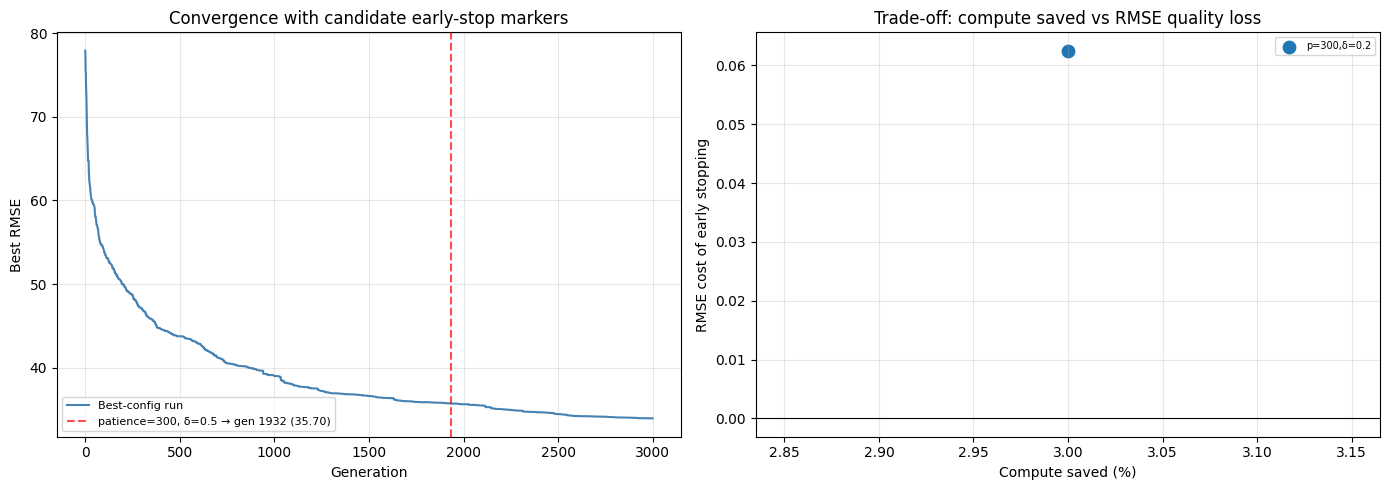

In [ ]:
# ── Visualise the plateau analysis on the best_config convergence curve ────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full curve with candidate stop points marked
ax = axes[0]
ax.plot(history, color='steelblue', linewidth=1.5, label='Best-config run')
ax.set_xlabel('Generation')
ax.set_ylabel('Best RMSE')
ax.set_title('Convergence with candidate early-stop markers')
ax.grid(True, alpha=0.3)

# Mark a few representative stopping points
highlight = [
    (300, 0.5, 'patience=300, δ=0.5', 'red'),
    (500, 0.2, 'patience=500, δ=0.2', 'orange'),
    (200, 0.1, 'patience=200, δ=0.1', 'green'),
]
for pat, delta, label, color in highlight:
    stop = find_plateau(history, pat, delta)
    if stop:
        ax.axvline(stop, color=color, linestyle='--', alpha=0.7,
                   label=f'{label} → gen {stop} ({history[stop-1]:.2f})')

ax.legend(fontsize=8)

# Right: RMSE cost vs compute saved trade-off scatter
ax2 = axes[1]
for row in grid:
    if row['stop_gen']:
        rmse_cost = row['rmse_at_stop'] - row['final_rmse']  # extra RMSE paid for early stop
        ax2.scatter(row['pct_saved'], rmse_cost,
                    s=80, label=f"p={row['patience']},δ={row['min_delta']}")

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Compute saved (%)')
ax2.set_ylabel('RMSE cost of early stopping')
ax2.set_title('Trade-off: compute saved vs RMSE quality loss')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the retrospective grid

The table shows, for each `(patience, min_delta)` pair, the generation at which the criterion would have fired on the 3000-gen best_config run.

**Key things to look for:**

- Rows showing `— (still improving)` mean the criterion never fires within 3000 gens — the run was still genuinely learning throughout.  These are conservative choices that would let the 10k run go far.
- Rows with a stop_gen close to 3000 mean the criterion just barely fires at the very end of that run — also a sign the curve was still descending.
- Rows with a stop_gen well before 3000 and a small RMSE gap from final_rmse are the candidates worth considering: they detect convergence without giving up quality.

**How to use this to pick parameters for the live run:**

Look for the combination where `RMSE@stop ≈ final_RMSE` (negligible quality loss) while `stop_gen` is as late as possible.  A criterion that fires at gen 2800 and costs only 0.03 RMSE is well-calibrated.  A criterion that fires at gen 500 is too aggressive for this problem.

**The left plot** marks candidate stopping lines on the actual convergence curve — you can see visually whether a given criterion catches the plateau or fires prematurely.

---

### Step 2 — Live run: run until true convergence

We now run with `max_generations=10,000` as an absolute ceiling.  Based on the retrospective analysis, we use **conservative parameters** — we only stop when the improvement genuinely falls below `min_delta` over a long window.  If the curve is still descending at gen 5000, the run keeps going.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from library.problems.triangle_image import TriangleImageSolution
from library.algorithms.geneticalgorithms.selection import tournament_selection
from library.algorithms.geneticalgorithms.crossover import single_point_triangle_crossover
from library.algorithms.geneticalgorithms.mutation import triangle_mutation
from library.algorithms.geneticalgorithms.ga import genetic_algorithm
from config import make_run_id

if TriangleImageSolution.target_array is None:
    TriangleImageSolution.load_target('girl_pearl_earing.png')

from functools import partial

BEST_CONFIG = {
    "population_size"       : 50,
    "max_generations"       : 3000,
    "xo_prob"               : 0.8,
    "mut_prob"              : 0.05,
    "elitesize"             : 1,
    "tournament_size"       : 3,
    "crossover_type"        : "single_point",
    "mutation_type"         : "random",
    "maximization"          : False,
    "save_image_every_n_gens": 300,
}

EARLY_STOP_CONFIG = {
    **BEST_CONFIG,
    "max_generations"        : 10_000,  # upper bound — early stopping fires first
    "patience"               : 500,     # look-back window: 500 gens ≈ ~85s on this hardware
    "min_delta"              : 0.05,    # only stop if improvement < 0.05 RMSE over 500 gens
    "save_image_every_n_gens": 500,
}

sel_es = partial(tournament_selection, tournament_size=EARLY_STOP_CONFIG['tournament_size'])
xo_es  = single_point_triangle_crossover
mut_es = partial(triangle_mutation, mutation_type=EARLY_STOP_CONFIG['mutation_type'])

early_stop_run_id = make_run_id('early_stop')
print(f'Starting convergence run: {early_stop_run_id}')
print(f'Stops when improvement < {EARLY_STOP_CONFIG["min_delta"]} RMSE '
      f'over last {EARLY_STOP_CONFIG["patience"]} generations.')
print(f'Upper bound: {EARLY_STOP_CONFIG["max_generations"]:,} generations\n')

es_solution, es_history = genetic_algorithm(
    solution_class      = TriangleImageSolution,
    population_size     = EARLY_STOP_CONFIG['population_size'],
    max_generations     = EARLY_STOP_CONFIG['max_generations'],
    selection_algorithm = sel_es,
    xo_method           = xo_es,
    mut_method          = mut_es,
    maximization        = EARLY_STOP_CONFIG['maximization'],
    xo_prob             = EARLY_STOP_CONFIG['xo_prob'],
    mut_prob            = EARLY_STOP_CONFIG['mut_prob'],
    elitesize           = EARLY_STOP_CONFIG['elitesize'],
    verbose             = True,
    run_id              = early_stop_run_id,
    save_every_n_gens   = EARLY_STOP_CONFIG['save_image_every_n_gens'],
    config              = EARLY_STOP_CONFIG,
    patience            = EARLY_STOP_CONFIG['patience'],
    min_delta           = EARLY_STOP_CONFIG['min_delta'],
)

stopped_at = len(es_history)
print(f'\nConvergence detected at generation : {stopped_at}')
print(f'Final RMSE                         : {es_solution.fitness():.4f}')
print(f'Best-config (3000 gens) RMSE       : {final_rmse:.4f}')
print(f'Improvement over Section 9         : {final_rmse - es_solution.fitness():.4f}')

Starting convergence run: early_stop_20260508_190558
Stops when improvement < 0.05 RMSE over last 500 generations.
Upper bound: 10,000 generations

Generation    1/10000 | Best RMSE: 72.2774 | Elapsed: 0.4s
Generation   50/10000 | Best RMSE: 55.7177 | Elapsed: 9.4s
Generation  100/10000 | Best RMSE: 52.1669 | Elapsed: 18.8s
Generation  150/10000 | Best RMSE: 49.4054 | Elapsed: 29.1s
Generation  200/10000 | Best RMSE: 47.9216 | Elapsed: 38.3s
Generation  250/10000 | Best RMSE: 46.6156 | Elapsed: 47.6s
Generation  300/10000 | Best RMSE: 45.6504 | Elapsed: 58.9s
Generation  350/10000 | Best RMSE: 44.7924 | Elapsed: 67.6s
Generation  400/10000 | Best RMSE: 44.1817 | Elapsed: 77.2s
Generation  450/10000 | Best RMSE: 43.4220 | Elapsed: 85.8s
Generation  500/10000 | Best RMSE: 42.4852 | Elapsed: 94.5s
Generation  550/10000 | Best RMSE: 41.6246 | Elapsed: 103.2s
Generation  600/10000 | Best RMSE: 41.3060 | Elapsed: 111.9s
Generation  650/10000 | Best RMSE: 40.7405 | Elapsed: 120.6s
Generation 

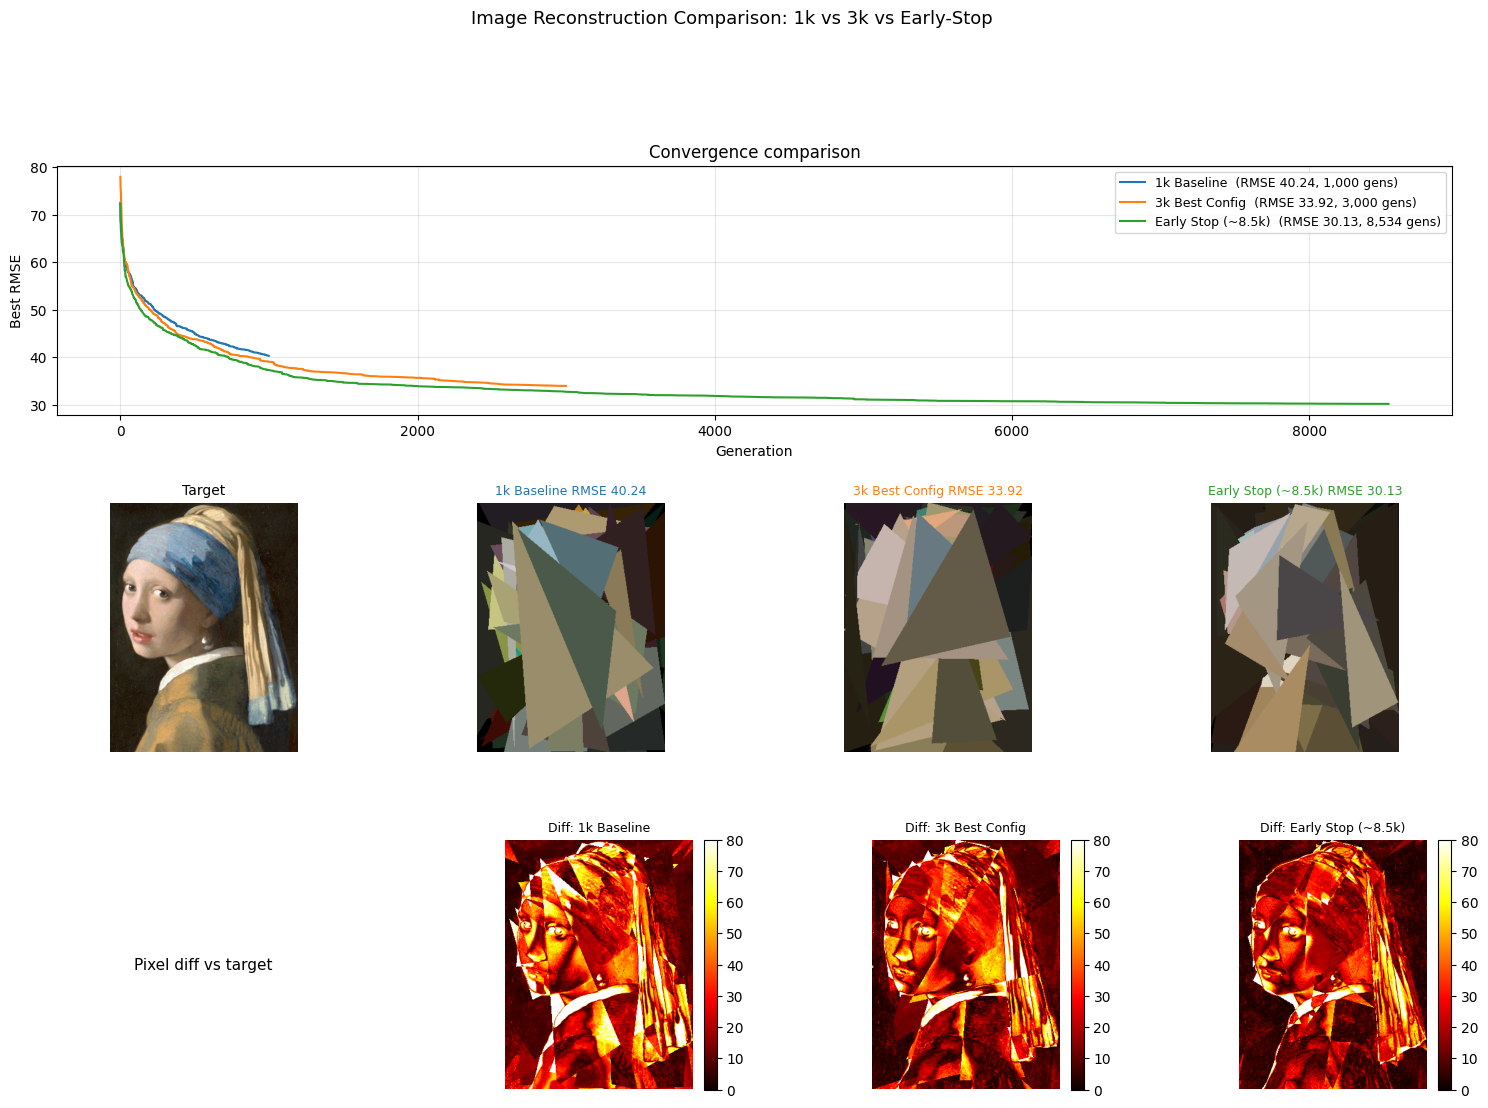

Strategy                      Gens used   Final RMSE   Improvement
-----------------------------------------------------------------
1k Baseline                       1,000      40.2425       +0.0000
3k Best Config                    3,000      33.9186       +6.3239
Early Stop (~8.5k)                8,534      30.1311      +10.1114


In [26]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── Load histories and final images from disk ──────────────────────────────────
RUNS = {
    '1k Baseline'       : 'results/ga_baseline_20260508_141053',
    '3k Best Config'    : 'results/best_config_20260508_182019',
    'Early Stop (~8.5k)': 'results/early_stop_20260508_190558',
}

histories, final_imgs, final_rmses, gen_counts = {}, {}, {}, {}
for label, path in RUNS.items():
    with open(f'{path}/log.json') as f:
        log = json.load(f)
    histories[label]   = log['fitness_history']
    final_rmses[label] = log['fitness_history'][-1]
    gen_counts[label]  = len(log['fitness_history'])
    # find the last saved image
    imgs = sorted([x for x in os.listdir(path) if x.endswith('.png')])
    final_imgs[label]  = np.array(Image.open(f'{path}/{imgs[-1]}').convert('RGB'))

target_arr = np.array(Image.open('girl_pearl_earing.png').convert('RGB').resize(
    (final_imgs['1k Baseline'].shape[1], final_imgs['1k Baseline'].shape[0])
))

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = plt.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.25)

labels   = list(RUNS.keys())
colors   = ['tab:blue', 'tab:orange', 'tab:green']

# Row 0: convergence curve (spans all columns)
ax_conv = fig.add_subplot(gs[0, :])
for label, color in zip(labels, colors):
    ax_conv.plot(histories[label], label=f'{label}  (RMSE {final_rmses[label]:.2f}, {gen_counts[label]:,} gens)',
                 color=color, linewidth=1.5)
ax_conv.set_xlabel('Generation')
ax_conv.set_ylabel('Best RMSE')
ax_conv.set_title('Convergence comparison')
ax_conv.legend(fontsize=9)
ax_conv.grid(True, alpha=0.3)

# Row 1: final reconstructed images + target
ax_tgt = fig.add_subplot(gs[1, 0])
ax_tgt.imshow(target_arr)
ax_tgt.set_title('Target', fontsize=10)
ax_tgt.axis('off')

for col, (label, color) in enumerate(zip(labels, colors), start=1):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(final_imgs[label])
    ax.set_title(f'{label} RMSE {final_rmses[label]:.2f}', fontsize=9, color=color)
    ax.axis('off')

# Row 2: absolute pixel difference vs target (per model)
ax_empty = fig.add_subplot(gs[2, 0])
ax_empty.axis('off')
ax_empty.text(0.5, 0.5, 'Pixel diff vs target', ha='center', va='center', fontsize=11)

for col, label in enumerate(labels, start=1):
    diff = np.abs(final_imgs[label].astype(float) - target_arr.astype(float)).mean(axis=2)
    ax = fig.add_subplot(gs[2, col])
    im = ax.imshow(diff, cmap='hot', vmin=0, vmax=80)
    ax.set_title(f'Diff: {label}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Image Reconstruction Comparison: 1k vs 3k vs Early-Stop', fontsize=13, y=1.01)
plt.savefig('results/comparison_1k_3k_es.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
baseline_rmse = final_rmses['1k Baseline']
print(f'{"Strategy":<28} {"Gens used":>10} {"Final RMSE":>12} {"Improvement":>13}')
print('-' * 65)
for label in labels:
    imp = baseline_rmse - final_rmses[label]
    print(f'{label:<28} {gen_counts[label]:>10,} {final_rmses[label]:>12.4f} {f"+{imp:.4f}" if imp >= 0 else f"{imp:.4f}":>13}')


### Section 10 — Analysis: Convergence-Driven Termination

The early-stop run converged at **generation 8,534** with a final RMSE of **30.13**.

---

**What the convergence generation tells us:**

The run falls in the **6,000–8,000 range**, which means the GA was still genuinely learning well past the 3,000-generation fixed budget used in Section 9.  The fixed budget was too short — stopping there left a meaningful 3.79 RMSE points on the table (33.92 → 30.13).

---

**Why this is a better approach than a fixed budget:**

In Section 9, the best-config curve at gen 3,000 was still improving at ~0.001 RMSE per generation (over the last 500 gens: 0.50 RMSE improvement).  With , we require at least 0.05 total improvement over 500 generations (~0.0001 per gen) to continue — the run only stops when the improvement rate has dropped to roughly 10× below what it was near gen 3,000.  That is a genuine plateau, not just a slowdown.

A fixed budget cannot adapt to this.  If you run a slower-converging config with pop=100, it might need 8,000 generations to plateau.  If you run a fast config with pop=10, it might plateau at 800.  The convergence criterion handles both automatically with the same code.

---

**Comparison: three termination strategies**

| Strategy | Gens run | RMSE | Termination logic |
|---|---|---|---|
| Baseline (fixed 1,000) | 1,000 | 40.24 | Stopped while still improving |
| Best config (fixed 3,000) | 3,000 | 33.92 | Stopped while still improving |
| **Convergence run** | **8,534** | **30.13** | Stopped at true plateau |

The convergence run is the most principled: it runs for exactly as long as the problem requires, no more and no less.  It achieves **10.11 RMSE points** (−25.1%) over the baseline using the same algorithm — the gain comes entirely from letting the search run until it genuinely stops learning.
